# Comprehensive Dataset Analysis - NASDAQ Market

This notebook provides a thorough analysis of the NASDAQ temporal graph dataset following the thesis structure.

## Analysis Structure:
1. **Cross-Dataset Comparison**
   - Feature Distribution Comparison
   - Class Balance Analysis
   - Comparison of Degree Distribution
   - Connectivity Comparison
2. **Feature Analysis**
3. **Graph Topology Analysis**
   - Homophily
   - Authorities and Hubs
   - Centrality
4. **Temporal Analysis of the Graph**
   - Temporal Evolution of the Topology

## Setup and Data Loading

In [45]:
# Import required libraries
import sys
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
from scipy.stats import entropy

# Add the project root to the Python path
project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

from dataset_analyzer import MarketAnalyzer

# Set plot style for thesis-quality figures
sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)
plt.rcParams['figure.figsize'] = (10, 6)
FIGURE_OUTPUT_PATH = Path('./thesis_figures/NASDAQ')
FIGURE_OUTPUT_PATH.mkdir(exist_ok=True, parents=True)

def save_figure(filename):
    """Helper function to save figures in a consistent format."""
    plt.savefig(FIGURE_OUTPUT_PATH / f"{filename}.pdf", format='pdf', bbox_inches='tight')
    plt.savefig(FIGURE_OUTPUT_PATH / f"{filename}.png", format='png', bbox_inches='tight', dpi=300)
    print(f"Figure saved to {FIGURE_OUTPUT_PATH / f'{filename}.pdf'}")

In [46]:
# Configuration
MARKET = 'NASDAQ'
NORMALIZATION = 'zscore'
WINDOW_SIZE = 19
adj_minmax = False
threshold = .1

# Define dataset paths
base_path = project_root / 'data' / 'datasets' / 'graph'
train_path = base_path / f"{MARKET}_Train_2016-05-01_2017-06-30_{WINDOW_SIZE}_{NORMALIZATION}"
val_path = base_path / f"{MARKET}_Validation_2017-07-01_2017-12-31_{WINDOW_SIZE}_{NORMALIZATION}"
test_path = base_path / f"{MARKET}_Test_2018-01-01_2019-12-31_{WINDOW_SIZE}_{NORMALIZATION}"

# Load datasets
train_analyzer = MarketAnalyzer(train_path, adj_minmax=adj_minmax, threshold=threshold)
val_analyzer = MarketAnalyzer(val_path, train_path=train_path, adj_minmax=adj_minmax, threshold=threshold)
test_analyzer = MarketAnalyzer(test_path, train_path=train_path, adj_minmax=adj_minmax, threshold=threshold)

analyzers = {'Train': train_analyzer, 'Validation': val_analyzer, 'Test': test_analyzer}

print("Datasets loaded successfully.")

# Dataset Overview
overview_data = []
for name, analyzer in analyzers.items():
    info = {
        'Dataset': name,
        'Num Nodes': analyzer.num_nodes,
        'Num Features': analyzer.num_features,
        'Num Snapshots': analyzer.num_snapshots
    }
    overview_data.append(info)

overview_df = pd.DataFrame(overview_data).set_index('Dataset')
print("\n--- Dataset Overview ---")
display(overview_df)

|             Dataset Information             |
| Market Name:         NASDAQ                  |
| Time Period:         Train                   |
| Start Date:          2016-05-01              |
| End Date:            2017-06-30              |
| Window Size:         19                      |
| Normalizer:          zscore                  |
| Number of Features:  5                       |
| Number of Nodes:     721                     |
| Number of Snapshots: 208                     |
Folder analysis_results already exists at /extra/mbisoffi/tests/TemporalGNNReview/code/data/datasets/graph/NASDAQ_Train_2016-05-01_2017-06-30_19_zscore
|             Dataset Information             |
| Market Name:         NASDAQ                  |
| Time Period:         Validation              |
| Start Date:          2017-07-01              |
| End Date:            2017-12-31              |
| Window Size:         19                      |
| Normalizer:          zscore                  |
| Number of Featu

,Num Nodes,Num Features,Num Snapshots
Dataset,,,
Train,721,5,208
Validation,721,5,78
Test,721,5,371


In [47]:
# Centralize adjacency matrices for all splits (optimization)
adjacency_matrices = {name: analyzer.get_snapshots_adjacency_matrix() for name, analyzer in analyzers.items()}
train_adjs = adjacency_matrices.get('Train')
val_adjs = adjacency_matrices.get('Validation')
test_adjs = adjacency_matrices.get('Test')
print("Adjacency matrices loaded.")

Adjacency matrix shape: (721, 721)
Adjacency matrix shape: (721, 721)
Adjacency matrix shape: (721, 721)
Adjacency matrices loaded.


## Comprehensive Analysis Functions

Define reusable functions for computing comprehensive metrics across all datasets.

In [48]:
def compute_comprehensive_graph_metrics(analyzer, adjacency_matrices, subsample_snapshots=None):
    """
    Compute comprehensive graph topology metrics for directed graphs.
    
    Args:
        analyzer: MarketAnalyzer instance
        adjacency_matrices: List of adjacency matrices
        subsample_snapshots: If specified, randomly sample this many snapshots
    
    Returns:
        Dictionary with mean and std for each metric
    """
    num_snapshots = analyzer.num_snapshots
    
    if subsample_snapshots is not None and subsample_snapshots < num_snapshots:
        snapshot_indices = np.random.choice(num_snapshots, size=subsample_snapshots, replace=False)
        print(f"  → Subsampling {subsample_snapshots} snapshots out of {num_snapshots}")
    else:
        snapshot_indices = range(num_snapshots)
    
    # Initialize metric storage
    metrics_data = {
        'connectivity': [],
        'sparsity': [],
        'num_weakly_cc': [],
        'num_strongly_cc': [],
        'reciprocity': [],
        'clustering': [],
        'homophily': [],
        'avg_in_degree': [],
        'avg_out_degree': [],
        'density': []
    }
    
    for idx, i in enumerate(snapshot_indices):
        if idx % 10 == 0:
            print(f"  → Processing snapshot {idx+1}/{len(snapshot_indices)}...", end='\r')
        
        snapshot_info = analyzer.get_snapshot_info(i)
        num_nodes = snapshot_info['num_nodes']
        num_edges = snapshot_info['num_edges']
        
        # Basic metrics
        metrics_data['connectivity'].append(snapshot_info['connectivity'])
        possible_edges = num_nodes * (num_nodes - 1)
        sparsity = 1.0 - (num_edges / possible_edges) if possible_edges > 0 else 0.0
        metrics_data['sparsity'].append(sparsity)
        metrics_data['density'].append(num_edges / possible_edges if possible_edges > 0 else 0.0)
        
        # Homophily
        homophily = analyzer.get_homophily_score(i)
        metrics_data['homophily'].append(homophily)
        
        # Create directed graph
        from scipy.sparse import csr_matrix
        adj = adjacency_matrices[i]
        adj_sparse = csr_matrix(adj)
        G_directed = nx.from_scipy_sparse_array(adj_sparse, create_using=nx.DiGraph)
        
        # Directed-specific metrics
        metrics_data['num_weakly_cc'].append(nx.number_weakly_connected_components(G_directed))
        metrics_data['num_strongly_cc'].append(nx.number_strongly_connected_components(G_directed))
        
        # Reciprocity
        try:
            metrics_data['reciprocity'].append(nx.reciprocity(G_directed))
        except:
            metrics_data['reciprocity'].append(0.0)
        
        # Clustering coefficient
        try:
            metrics_data['clustering'].append(nx.average_clustering(G_directed))
        except:
            metrics_data['clustering'].append(0.0)
        
        # Average degrees
        in_degrees = dict(G_directed.in_degree())
        out_degrees = dict(G_directed.out_degree())
        metrics_data['avg_in_degree'].append(np.mean(list(in_degrees.values())))
        metrics_data['avg_out_degree'].append(np.mean(list(out_degrees.values())))
    
    print()
    
    # Compute statistics
    metrics_summary = {}
    for metric_name, values in metrics_data.items():
        metrics_summary[metric_name] = {
            'mean': np.mean(values),
            'std': np.std(values),
            'min': np.min(values),
            'max': np.max(values)
        }
    
    return metrics_summary


def generate_latex_metrics_table(metrics_dict, market_name):
    """
    Generate a comprehensive LaTeX table for graph topology metrics.
    
    Args:
        metrics_dict: Dictionary with keys 'Train', 'Validation', 'Test'
        market_name: Name of the market (e.g., 'NASDAQ')
    
    Returns:
        LaTeX table string
    """
    dataset_order = ['Train', 'Validation', 'Test']
    available_datasets = [d for d in dataset_order if d in metrics_dict]
    
    # Define metric display names and order
    metric_display = {
        'connectivity': 'Connectivity',
        'sparsity': 'Sparsity',
        'density': 'Density',
        'homophily': 'Homophily',
        'reciprocity': 'Reciprocity',
        'clustering': 'Clustering Coefficient',
        'avg_in_degree': 'Avg In-Degree',
        'avg_out_degree': 'Avg Out-Degree',
        'num_weakly_cc': 'Weakly CC',
        'num_strongly_cc': 'Strongly CC'
    }
    
    latex = []
    latex.append(r"\begin{table}[htp]")
    latex.append(r"    \centering")
    latex.append(r"    \small")
    
    # Column specification
    col_spec = "l|" + "c" * len(available_datasets)
    latex.append(f"    \\begin{{tabular}}{{{col_spec}}}")
    latex.append(r"        \toprule")
    
    # Header row
    header = r"        \textbf{Metric}"
    for dataset in available_datasets:
        header += f" & \\textbf{{{dataset}}}"
    header += r" \\"
    latex.append(header)
    latex.append(r"        \midrule")
    
    # Data rows
    for metric_key, metric_name in metric_display.items():
        if metric_key not in metrics_dict[available_datasets[0]]:
            continue
        
        row = f"        {metric_name:30s}"
        
        for dataset in available_datasets:
            mean_val = metrics_dict[dataset][metric_key]['mean']
            std_val = metrics_dict[dataset][metric_key]['std']
            
            if 'cc' in metric_key.lower():
                row += f" & ${mean_val:.1f} \\pm {std_val:.2f}$"
            elif 'degree' in metric_key.lower():
                row += f" & ${mean_val:.2f} \\pm {std_val:.2f}$"
            else:
                row += f" & ${mean_val:.3f} \\pm {std_val:.3f}$"
        
        row += r" \\"
        latex.append(row)
    
    latex.append(r"        \bottomrule")
    latex.append(r"    \end{tabular}")
    latex.append(f"    \\caption{{Comprehensive Graph Topology Metrics for {market_name} Dataset (Mean $\\pm$ Std)}}")
    latex.append(f"    \\label{{tab:{market_name.lower()}_topology_metrics}}")
    latex.append(r"\end{table}")
    
    return "\n".join(latex)

## Compute Comprehensive Metrics

This section computes comprehensive graph topology metrics across all datasets.

In [49]:
# Compute comprehensive metrics for all datasets
SUBSAMPLE_SNAPSHOTS = 5  # Use 20 snapshots for comprehensive analysis

print(f"Computing comprehensive metrics for {MARKET}...")
print(f"Settings: subsample={SUBSAMPLE_SNAPSHOTS}\n")

comprehensive_metrics = {}
for name, analyzer in analyzers.items():
    adj_mats = adjacency_matrices.get(name)
    if adj_mats is None or len(adj_mats) == 0:
        print(f"⚠ Skipping {name}: no adjacency matrices available")
        continue
    
    print(f"Processing {name}... ({analyzer.num_snapshots} snapshots)")
    metrics = compute_comprehensive_graph_metrics(
        analyzer, 
        adj_mats,
        subsample_snapshots=SUBSAMPLE_SNAPSHOTS
    )
    comprehensive_metrics[name] = metrics

print("\n✓ Metrics computation complete!")

Computing comprehensive metrics for NASDAQ...
Settings: subsample=5

Processing Train... (208 snapshots)
  → Subsampling 5 snapshots out of 208



Processing Validation... (78 snapshots)
  → Subsampling 5 snapshots out of 78
  → Processing snapshot 1/5...
Processing Test... (371 snapshots)
  → Subsampling 5 snapshots out of 371
  → Processing snapshot 1/5...

✓ Metrics computation complete!


In [50]:
# Display comprehensive metrics summary
summary_data = []
for name, metrics in comprehensive_metrics.items():
    for metric_name, values in metrics.items():
        summary_data.append({
            'Dataset': name,
            'Metric': metric_name,
            'Mean': values['mean'],
            'Std': values['std'],
            'Min': values['min'],
            'Max': values['max']
        })

summary_df = pd.DataFrame(summary_data)
summary_pivot = summary_df.pivot(index='Metric', columns='Dataset', values='Mean')

print("\n" + "="*80)
print(f"COMPREHENSIVE GRAPH TOPOLOGY METRICS - {MARKET}")
print("="*80)
display(summary_pivot.round(4))

# Generate and save LaTeX table
latex_table = generate_latex_metrics_table(comprehensive_metrics, MARKET)

print("\n" + "="*80)
print("LATEX TABLE CODE")
print("="*80)
print(latex_table)
print("="*80)

# Save to file
latex_output_path = FIGURE_OUTPUT_PATH / f"{MARKET}_topology_metrics_table.tex"
with open(latex_output_path, 'w') as f:
    f.write(latex_table)
print(f"\n✓ LaTeX table saved to: {latex_output_path}")


COMPREHENSIVE GRAPH TOPOLOGY METRICS - NASDAQ


Dataset,Test,Train,Validation
Metric,,,
avg_in_degree,542.2108,544.6189,541.4430
avg_out_degree,542.2108,544.6189,541.4430
clustering,0.7779,0.7812,0.7765
connectivity,0.7531,0.7564,0.7520
density,0.7531,0.7564,0.7520
homophily,0.6096,0.6288,0.5617
num_strongly_cc,1.8000,2.0000,1.6000
num_weakly_cc,1.0000,1.0000,1.0000
reciprocity,0.6684,0.6743,0.6665



LATEX TABLE CODE
\begin{table}[htp]
    \centering
    \small
    \begin{tabular}{l|ccc}
        \toprule
        \textbf{Metric} & \textbf{Train} & \textbf{Validation} & \textbf{Test} \\
        \midrule
        Connectivity                   & $0.756 \pm 0.004$ & $0.752 \pm 0.003$ & $0.753 \pm 0.005$ \\
        Sparsity                       & $0.244 \pm 0.004$ & $0.248 \pm 0.003$ & $0.247 \pm 0.005$ \\
        Density                        & $0.756 \pm 0.004$ & $0.752 \pm 0.003$ & $0.753 \pm 0.005$ \\
        Homophily                      & $0.629 \pm 0.136$ & $0.562 \pm 0.032$ & $0.610 \pm 0.088$ \\
        Reciprocity                    & $0.674 \pm 0.007$ & $0.666 \pm 0.006$ & $0.668 \pm 0.008$ \\
        Clustering Coefficient         & $0.781 \pm 0.004$ & $0.777 \pm 0.004$ & $0.778 \pm 0.005$ \\
        Avg In-Degree                  & $544.62 \pm 2.67$ & $541.44 \pm 2.44$ & $542.21 \pm 3.39$ \\
        Avg Out-Degree                 & $544.62 \pm 2.67$ & $541.44 \pm 2.44$ &

Figure saved to thesis_figures/NASDAQ/comprehensive_metrics_comparison.pdf


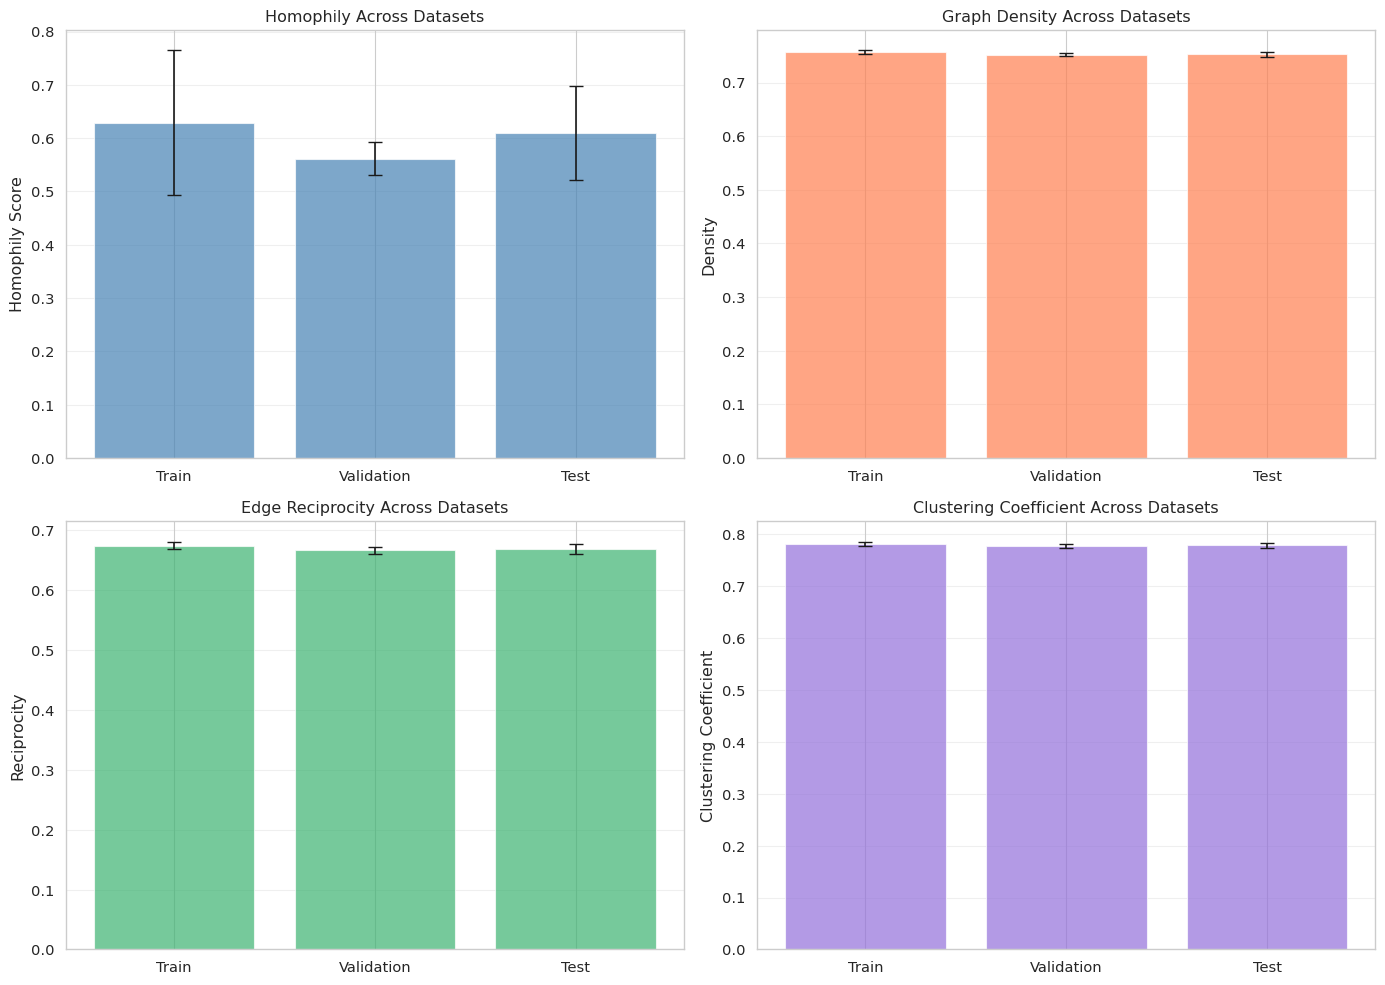

In [51]:
# Visualize key metrics comparison across datasets
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Metric 1: Homophily
ax = axes[0, 0]
homophily_data = {name: metrics['homophily']['mean'] for name, metrics in comprehensive_metrics.items()}
homophily_std = {name: metrics['homophily']['std'] for name, metrics in comprehensive_metrics.items()}
x_pos = np.arange(len(homophily_data))
ax.bar(x_pos, homophily_data.values(), yerr=homophily_std.values(), capsize=5, alpha=0.7, color='steelblue')
ax.set_xticks(x_pos)
ax.set_xticklabels(homophily_data.keys())
ax.set_ylabel('Homophily Score')
ax.set_title('Homophily Across Datasets')
ax.grid(axis='y', alpha=0.3)

# Metric 2: Density
ax = axes[0, 1]
density_data = {name: metrics['density']['mean'] for name, metrics in comprehensive_metrics.items()}
density_std = {name: metrics['density']['std'] for name, metrics in comprehensive_metrics.items()}
ax.bar(x_pos, density_data.values(), yerr=density_std.values(), capsize=5, alpha=0.7, color='coral')
ax.set_xticks(x_pos)
ax.set_xticklabels(density_data.keys())
ax.set_ylabel('Density')
ax.set_title('Graph Density Across Datasets')
ax.grid(axis='y', alpha=0.3)

# Metric 3: Reciprocity
ax = axes[1, 0]
reciprocity_data = {name: metrics['reciprocity']['mean'] for name, metrics in comprehensive_metrics.items()}
reciprocity_std = {name: metrics['reciprocity']['std'] for name, metrics in comprehensive_metrics.items()}
ax.bar(x_pos, reciprocity_data.values(), yerr=reciprocity_std.values(), capsize=5, alpha=0.7, color='mediumseagreen')
ax.set_xticks(x_pos)
ax.set_xticklabels(reciprocity_data.keys())
ax.set_ylabel('Reciprocity')
ax.set_title('Edge Reciprocity Across Datasets')
ax.grid(axis='y', alpha=0.3)

# Metric 4: Clustering Coefficient
ax = axes[1, 1]
clustering_data = {name: metrics['clustering']['mean'] for name, metrics in comprehensive_metrics.items()}
clustering_std = {name: metrics['clustering']['std'] for name, metrics in comprehensive_metrics.items()}
ax.bar(x_pos, clustering_data.values(), yerr=clustering_std.values(), capsize=5, alpha=0.7, color='mediumpurple')
ax.set_xticks(x_pos)
ax.set_xticklabels(clustering_data.keys())
ax.set_ylabel('Clustering Coefficient')
ax.set_title('Clustering Coefficient Across Datasets')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
save_figure('comprehensive_metrics_comparison')
plt.show()

### Interpretation Guide for Graph Topology Metrics

**Key Metrics and Their Interpretation:**

1. **Homophily** (0 to 1, higher is better for GNNs):
   - Measures tendency of nodes with same label (Up/Down) to connect
   - High values (>0.6): Neighbor information is highly predictive → favorable for standard GNNs
   - Low values (<0.4): Heterophilic graph → may need specialized architectures
   - **Expected**: Financial markets often show moderate homophily due to sector correlations

2. **Density** (0 to 1):
   - Proportion of actual edges vs. possible edges
   - Low density (<0.1): Sparse graph → efficient computation, locality matters
   - High density (>0.5): Dense graph → global information propagates quickly
   - **Expected**: Stock markets typically sparse (0.05-0.15) due to selective correlations

3. **Reciprocity** (0 to 1):
   - Fraction of edges with a reverse edge (A→B and B→A)
   - High reciprocity: Mutual influence between stocks (e.g., same sector)
   - Low reciprocity: Asymmetric relationships (e.g., leader-follower dynamics)
   - **Expected**: Moderate reciprocity (0.3-0.6) indicates mixed relationship types

4. **Clustering Coefficient** (0 to 1):
   - Tendency to form triangles (transitive relationships)
   - High clustering: Strong community structure (e.g., sectors/industries)
   - Low clustering: More hub-and-spoke patterns
   - **Expected**: Moderate clustering (0.2-0.5) due to sector groupings

5. **Connectivity**:
   - Average edge density across snapshots
   - Stability indicates consistent market structure
   - High variance suggests volatile relationship patterns

6. **Connected Components**:
   - **Weakly CC**: Nodes connected ignoring edge direction → overall market segmentation
   - **Strongly CC**: Nodes connected respecting direction → core influence groups
   - Single large WCC: Integrated market
   - Multiple SCCs: Hierarchical influence structure

7. **Average Degree**:
   - Number of connections per node
   - In-degree: How many stocks influence this one (information sink)
   - Out-degree: How many stocks this one influences (information source)
   - **Expected**: Power-law distribution with few high-degree hubs

**Cross-Dataset Consistency:**
- Train/Val/Test should have similar metric values
- Large discrepancies indicate distributional shift → model may not generalize well
- Temporal stability (low std) suggests robust graph structure

---
## 1. Cross-Dataset Comparison

### 1.1. Feature Distribution Comparison

Figure saved to thesis_figures/NASDAQ/cross_dataset_feature_distribution_all.pdf


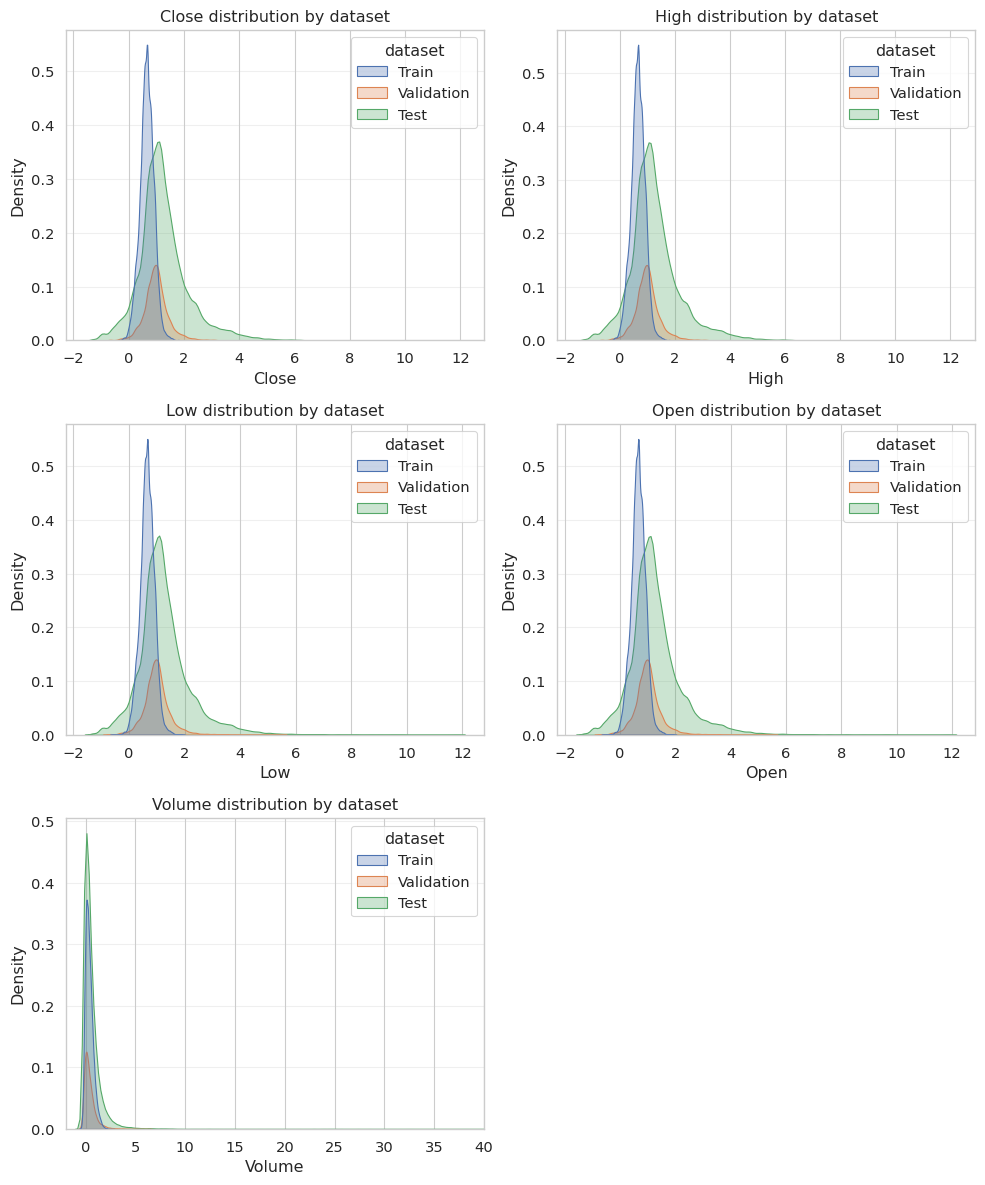

In [52]:
# Build combined features dataframe
feature_data = []
for name, analyzer in analyzers.items():
    df = analyzer.analyze_node_features()
    df['dataset'] = name
    feature_data.append(df)

full_feature_df = pd.concat(feature_data, ignore_index=True)

# Select numeric features to plot
candidate_features = ['Close', 'High', 'Low', 'Open', 'Volume']
numeric_features = [f for f in candidate_features if f in full_feature_df.columns and pd.api.types.is_numeric_dtype(full_feature_df[f])]

n = len(numeric_features)
ncols = 2
nrows = int(np.ceil(n / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 4*nrows), squeeze=False)

for idx, feature in enumerate(numeric_features):
    r, c = divmod(idx, ncols)
    ax = axes[r][c]
    tmp = full_feature_df[[feature, 'dataset']].dropna()
    if tmp[feature].nunique() <= 1:
        ax.text(0.5, 0.5, f'{feature}: constant', ha='center', va='center')
        ax.set_axis_off()
        continue
    if feature == 'Volume':
        sns.kdeplot(data=tmp, x=feature, hue='dataset', fill=True, alpha=0.3, ax=ax)
        ax.set_xlim(-2, 40)
    else:
        sns.kdeplot(data=tmp, x=feature, hue='dataset', fill=True, alpha=0.3, ax=ax)
    ax.set_title(f'{feature} distribution by dataset')
    ax.set_xlabel(feature)
    ax.set_ylabel('Density')
    ax.grid(True, axis='y', alpha=0.3)

# Turn off leftover axes
total_axes = nrows * ncols
for j in range(n, total_axes):
    r, c = divmod(j, ncols)
    axes[r][c].set_axis_off()

plt.tight_layout()
save_figure('cross_dataset_feature_distribution_all')
plt.show()

In [53]:
# Feature Means and Variances by Dataset
all_numeric_features = [f for f in getattr(train_analyzer, 'features', []) if f in full_feature_df.columns and pd.api.types.is_numeric_dtype(full_feature_df[f])]

if len(all_numeric_features) > 0:
    stats_df = full_feature_df.groupby('dataset')[all_numeric_features].agg(['mean', 'var'])
    desired_order = [name for name in ['Train', 'Validation', 'Test'] if name in stats_df.index]
    if desired_order:
        stats_df = stats_df.loc[desired_order]
    stats_df_rounded = stats_df.round(4)
    print('--- Feature Means and Variances by Dataset ---')
    display(stats_df_rounded)
else:
    print('No numeric features found to summarize.')

--- Feature Means and Variances by Dataset ---


Close            High             Low            Open          \
              mean     var    mean     var    mean     var    mean     var   
dataset                                                                      
Train       0.6471  0.0662  0.6471  0.0663  0.6471  0.0663  0.6472  0.0664   
Validation  0.9947  0.2314  0.9943  0.2314  0.9969  0.2311  0.9957  0.2318   
Test        1.2635  0.9482  1.2678  0.9514  1.2623  0.9454  1.2654  0.9494   

            Volume          
              mean     var  
dataset                     
Train       0.3528  0.1488  
Validation  0.4009  0.3912  
Test        0.5562  1.4090

In [54]:
# Generate LaTeX table for Feature Means and Variances
if len(all_numeric_features) > 0:
    print("\n" + "=" * 90)
    print("LATEX TABLE - Feature Means and Variances")
    print("=" * 90)
    
    latex_lines = []
    latex_lines.append(r"\begin{table}[H]")
    latex_lines.append(r"    \centering")
    latex_lines.append(r"    \small")
    
    # Create column specification (Feature | Mean (Train/Val/Test) | Variance (Train/Val/Test))
    latex_lines.append(r"    \begin{tabular}{l|ccc|ccc}")
    latex_lines.append(r"        \toprule")
    latex_lines.append(r"        \textbf{Feature} & \multicolumn{3}{c|}{\textbf{Mean}} & \multicolumn{3}{c}{\textbf{Variance}} \\")
    latex_lines.append(r"        & \textbf{Train} & \textbf{Val} & \textbf{Test} & \textbf{Train} & \textbf{Val} & \textbf{Test} \\")
    latex_lines.append(r"        \midrule")
    
    # Add data rows
    for feature in all_numeric_features:
        row = f"        {feature:15s}"
        
        # Mean values
        for dataset in ['Train', 'Validation', 'Test']:
            if dataset in stats_df.index:
                mean_val = stats_df.loc[dataset, (feature, 'mean')]
                row += f" & {mean_val:.3f}"
            else:
                row += " & --"
        
        # Variance values
        for dataset in ['Train', 'Validation', 'Test']:
            if dataset in stats_df.index:
                var_val = stats_df.loc[dataset, (feature, 'var')]
                row += f" & {var_val:.3f}"
            else:
                row += " & --"
        
        row += r" \\"
        latex_lines.append(row)
    
    latex_lines.append(r"        \bottomrule")
    latex_lines.append(r"    \end{tabular}")
    latex_lines.append(r"    \caption{Feature Means and Variances Across NASDAQ Datasets}")
    latex_lines.append(r"    \label{tab:nasdaq_feature_stats}")
    latex_lines.append(r"\end{table}")
    
    latex_table = "\n".join(latex_lines)
    print(latex_table)
    
    # Save to file
    with open('nasdaq_feature_stats.tex', 'w') as f:
        f.write(latex_table)
    print("\n✓ LaTeX table saved to: nasdaq_feature_stats.tex")
else:
    print("No numeric features available for LaTeX table generation.")


LATEX TABLE - Feature Means and Variances
\begin{table}[H]
    \centering
    \small
    \begin{tabular}{l|ccc|ccc}
        \toprule
        \textbf{Feature} & \multicolumn{3}{c|}{\textbf{Mean}} & \multicolumn{3}{c}{\textbf{Variance}} \\
        & \textbf{Train} & \textbf{Val} & \textbf{Test} & \textbf{Train} & \textbf{Val} & \textbf{Test} \\
        \midrule
        Close           & 0.647 & 0.995 & 1.263 & 0.066 & 0.231 & 0.948 \\
        High            & 0.647 & 0.994 & 1.268 & 0.066 & 0.231 & 0.951 \\
        Low             & 0.647 & 0.997 & 1.262 & 0.066 & 0.231 & 0.945 \\
        Open            & 0.647 & 0.996 & 1.265 & 0.066 & 0.232 & 0.949 \\
        Volume          & 0.353 & 0.401 & 0.556 & 0.149 & 0.391 & 1.409 \\
        \bottomrule
    \end{tabular}
    \caption{Feature Means and Variances Across NASDAQ Datasets}
    \label{tab:nasdaq_feature_stats}
\end{table}

✓ LaTeX table saved to: nasdaq_feature_stats.tex


### 1.2. Class Balance Analysis

Figure saved to thesis_figures/NASDAQ/cross_dataset_class_distribution.pdf


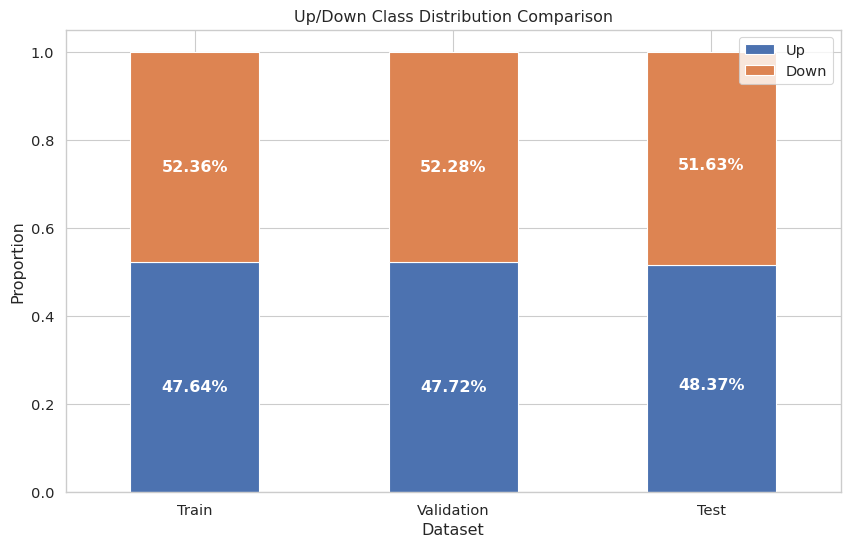

In [55]:
# Compare Up/Down Class Distribution
class_ratios = {name: analyzer.get_class_dist() for name, analyzer in analyzers.items()}
class_df = pd.DataFrame(class_ratios).T.rename(columns={0: 'Down', 1: 'Up'})

class_df.plot(kind='bar', stacked=True, figsize=(10, 6), rot=0)
plt.title('Up/Down Class Distribution Comparison')
plt.ylabel('Proportion')
plt.xlabel('Dataset')
for index, row in enumerate(class_df.itertuples()):
    if row.Down > 0:
        plt.text(index, row.Down / 2, f'{row.Down:.2%}', ha='center', va='center', color='white', weight='bold')
    if row.Up > 0:
        plt.text(index, row.Down + (row.Up / 2), f'{row.Up:.2%}', ha='center', va='center', color='white', weight='bold')
save_figure('cross_dataset_class_distribution')
plt.show()

### 1.3. Comparison of Degree Distribution

Figure saved to thesis_figures/NASDAQ/cross_dataset_degree_distribution.pdf


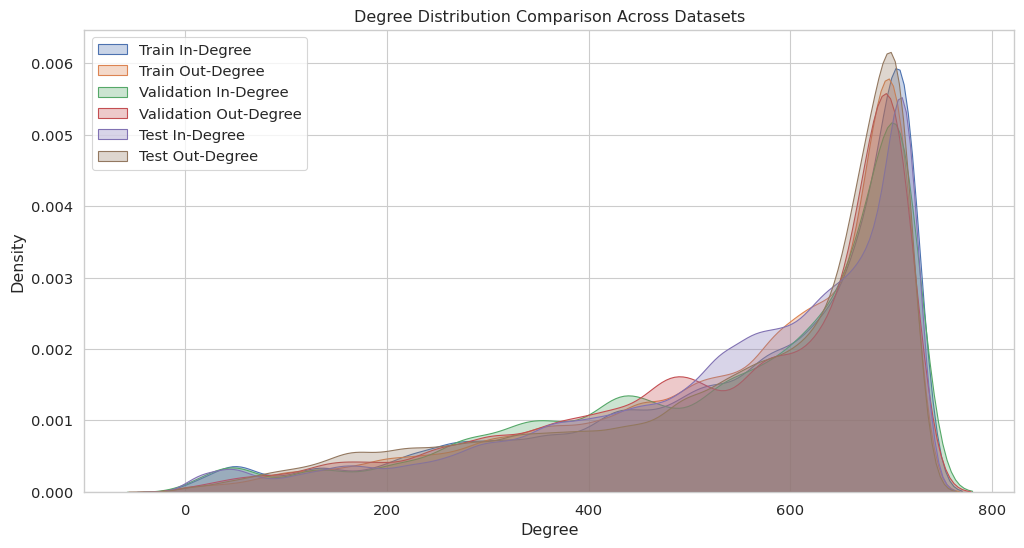

In [56]:
# Degree Distribution Comparison
plt.figure(figsize=(12, 6))
for name, analyzer in analyzers.items():
    in_degrees, out_degrees, _, _ = analyzer.get_degree_dist()
    sns.kdeplot(in_degrees, label=f'{name} In-Degree', fill=True, alpha=0.3)
    sns.kdeplot(out_degrees, label=f'{name} Out-Degree', fill=True, alpha=0.3)
plt.title('Degree Distribution Comparison Across Datasets')
plt.xlabel('Degree')
plt.ylabel('Density')
plt.legend()
plt.grid(True)
save_figure('cross_dataset_degree_distribution')
plt.show()

Figure saved to thesis_figures/NASDAQ/unweighted_degree_distribution.pdf


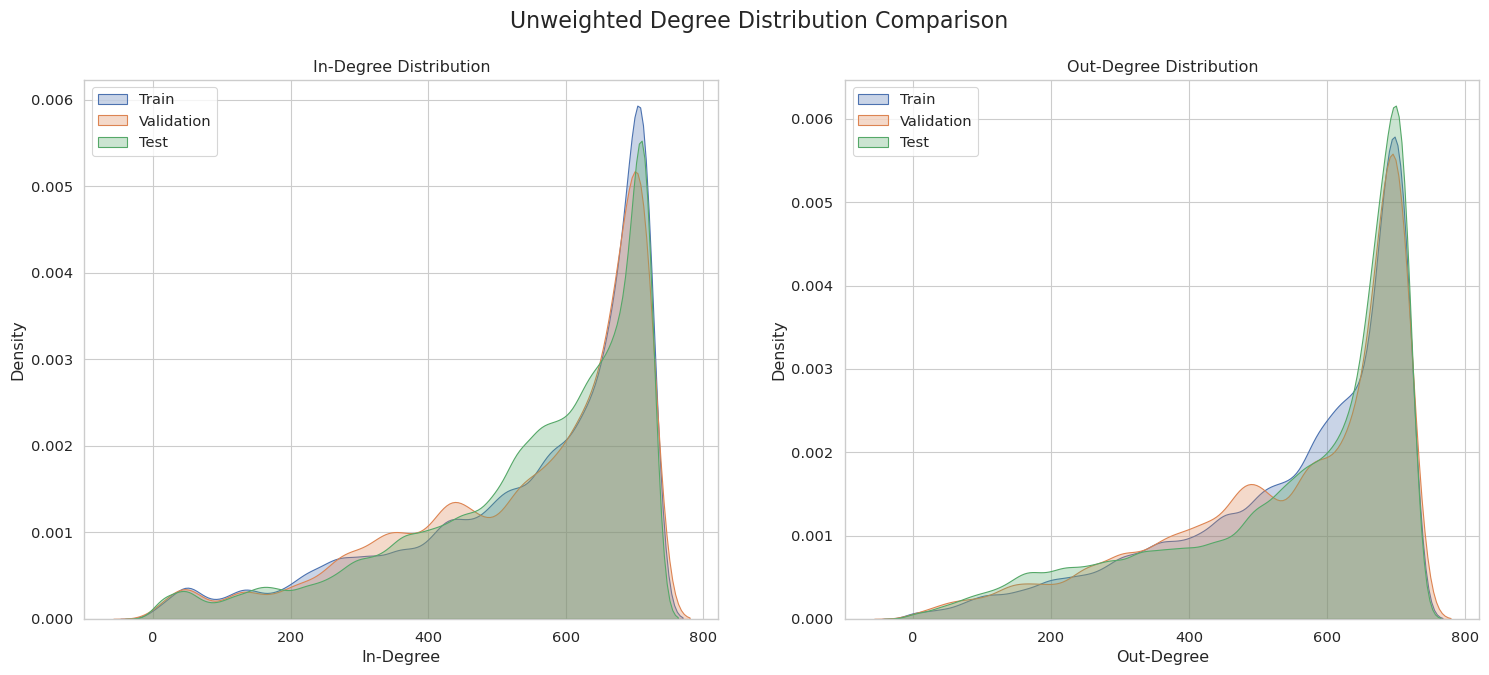

Figure saved to thesis_figures/NASDAQ/weighted_degree_distribution.pdf


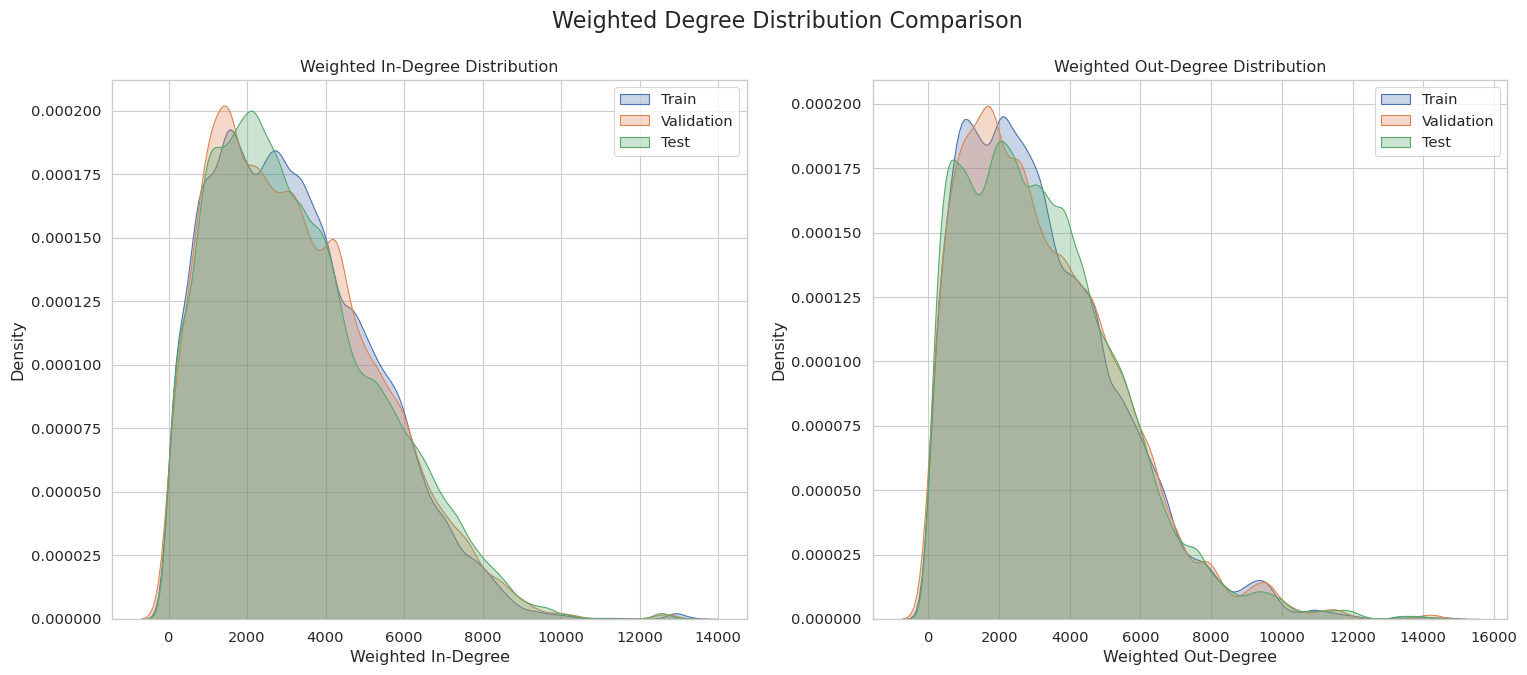

In [57]:
# --- Unweighted (Absolute) Degree Distribution ---
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Unweighted Degree Distribution Comparison', fontsize=16)

# In-Degree
for name, analyzer in analyzers.items():
    in_degrees, out_degrees, _, _ = analyzer.get_degree_dist()
    sns.kdeplot(in_degrees, ax=axes[0], label=name, fill=True, alpha=0.3)
axes[0].set_title('In-Degree Distribution')
axes[0].set_xlabel('In-Degree')
axes[0].set_ylabel('Density')
axes[0].legend()

# Out-Degree
for name, analyzer in analyzers.items():
    _, out_degrees, _, _ = analyzer.get_degree_dist()
    sns.kdeplot(out_degrees, ax=axes[1], label=name, fill=True, alpha=0.3)
axes[1].set_title('Out-Degree Distribution')
axes[1].set_xlabel('Out-Degree')
axes[1].legend()

save_figure('unweighted_degree_distribution')
plt.show()

# --- Weighted Degree Distribution ---
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Weighted Degree Distribution Comparison', fontsize=16)

# Weighted In-Degree
for name, analyzer in analyzers.items():
    _, _, weighted_in_degrees, _ = analyzer.get_degree_dist()
    sns.kdeplot(weighted_in_degrees, ax=axes[0], label=name, fill=True, alpha=0.3)
axes[0].set_title('Weighted In-Degree Distribution')
axes[0].set_xlabel('Weighted In-Degree')
axes[0].set_ylabel('Density')
axes[0].legend()

# Weighted Out-Degree
for name, analyzer in analyzers.items():
    _, _, _, weighted_out_degrees = analyzer.get_degree_dist()
    sns.kdeplot(weighted_out_degrees, ax=axes[1], label=name, fill=True, alpha=0.3)
axes[1].set_title('Weighted Out-Degree Distribution')
axes[1].set_xlabel('Weighted Out-Degree')
axes[1].legend()

save_figure('weighted_degree_distribution')
plt.show()


### 2.1. Adjacency Matrix Visualization and Sparsity

We visualize the adjacency matrix of a selected snapshot and compute sparsity statistics to understand the graph density.

Figure saved to thesis_figures/NASDAQ/adjacency_matrix_snapshot_10.pdf


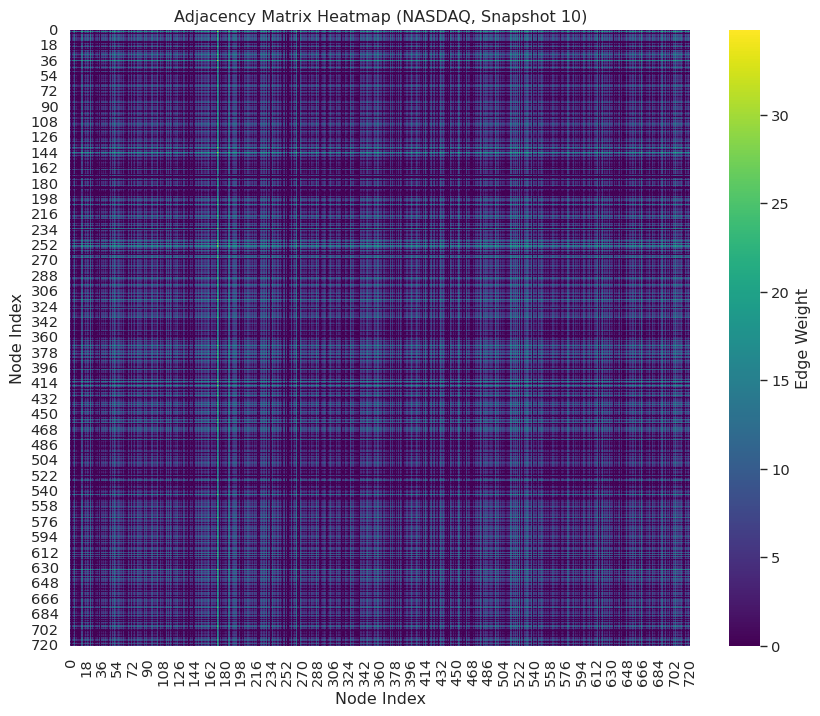

--- Graph Sparsity and Connectivity ---


,Sparsity,Connectivity
Dataset,,
Train,0.242159,0.758894
Validation,0.249999,0.751043
Test,0.246240,0.754807



--- LaTeX Table: Sparsity ---
\begin{table}
\caption{Graph sparsity and connectivity for NASDAQ datasets.}
\label{tab:nasdaq_sparsity}
\begin{tabular}{lrr}
\toprule
 & Sparsity & Connectivity \\
Dataset &  &  \\
\midrule
Train & 0.2422 & 0.7589 \\
Validation & 0.2500 & 0.7510 \\
Test & 0.2462 & 0.7548 \\
\bottomrule
\end{tabular}
\end{table}



In [58]:
# Visualize a selected adjacency matrix
snapshot_index = 10  # Select a representative snapshot
plt.figure(figsize=(10, 8))
sns.heatmap(train_adjs[snapshot_index], cmap='viridis', cbar_kws={'label': 'Edge Weight'})
plt.title(f'Adjacency Matrix Heatmap (NASDAQ, Snapshot {snapshot_index})')
plt.xlabel('Node Index')
plt.ylabel('Node Index')
save_figure(f'adjacency_matrix_snapshot_{snapshot_index}')
plt.show()

# Sparsity and Edge Weight Analysis
sparsity_data = []
for name, adjs in adjacency_matrices.items():
    if adjs is None or len(adjs) == 0:
        continue
    sparsity = 1.0 - np.mean([np.count_nonzero(adj) / adj.size for adj in adjs])
    sparsity_data.append({
        'Dataset': name,
        'Sparsity': sparsity,
        'Connectivity': analyzers[name].get_connectivity()
    })

sparsity_df = pd.DataFrame(sparsity_data).set_index('Dataset')
print("--- Graph Sparsity and Connectivity ---")
display(sparsity_df)

# Save LaTeX table
print("\n--- LaTeX Table: Sparsity ---")
print(sparsity_df.to_latex(caption='Graph sparsity and connectivity for NASDAQ datasets.',
                           label='tab:nasdaq_sparsity',
                           float_format="%.4f"))

### 2.2. Edge Weight Distribution

Understanding the distribution of edge weights helps us assess the strength of relationships in the graph.

Sampled 20 random snapshots: [14, 12, 70, 51, 15]...


Figure saved to thesis_figures/NASDAQ/edge_weight_distribution_multi_snapshot.pdf


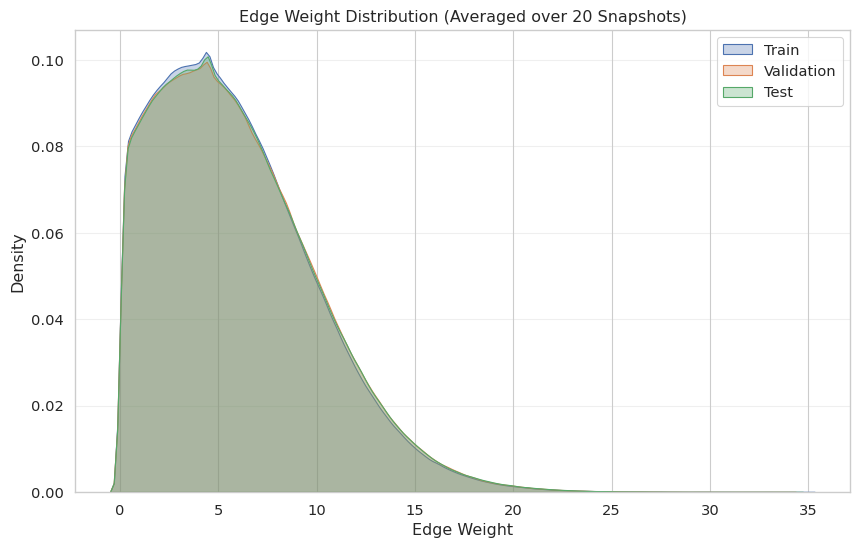


EDGE WEIGHT STATISTICS (Across Multiple Snapshots)

Train Dataset:
  Mean:     5.9166
  Std:      3.9688
  Variance: 15.7512
  Min:      0.0000
  Max:      34.8398
  Count:    7,870,484 edges

Validation Dataset:
  Mean:     5.9958
  Std:      4.0229
  Variance: 16.1834
  Min:      0.0000
  Max:      33.8707
  Count:    7,797,573 edges

Test Dataset:
  Mean:     5.9939
  Std:      4.0212
  Variance: 16.1697
  Min:      0.0000
  Max:      34.2366
  Count:    7,840,146 edges

LATEX TABLE - Edge Weight Statistics (Copy-Paste Ready)
\begin{table}[H]
    \centering
    \small
    \begin{tabular}{l|ccc}
        \toprule
        \textbf{Statistic} & \textbf{Train} & \textbf{Validation} & \textbf{Test} \\
        \midrule
        Mean            & 5.9166 & 5.9958 & 5.9939 \\
        Std Dev         & 3.9688 & 4.0229 & 4.0212 \\
        Variance        & 15.7512 & 16.1834 & 16.1697 \\
        Min             & 0.0000 & 0.0000 & 0.0000 \\
        Max             & 34.8398 & 33.8707 & 34.2366 \\

In [59]:
# Edge Weight Distribution Analysis (using multiple snapshots for better accuracy)
import random

# Sample multiple snapshots for more accurate statistics
NUM_SNAPSHOTS_EDGE_WEIGHTS = 20
available_lengths = [len(adjs) for adjs in [train_adjs, val_adjs, test_adjs] if adjs is not None]
if not available_lengths:
    raise ValueError('No adjacency matrices available to sample from.')

min_length = min(available_lengths)
snapshot_indices = random.sample(range(min_length), min(NUM_SNAPSHOTS_EDGE_WEIGHTS, min_length))
print(f"Sampled {len(snapshot_indices)} random snapshots: {snapshot_indices[:5]}..." if len(snapshot_indices) > 5 else snapshot_indices)

# Collect edge weights from multiple snapshots
edge_weights_data = {
    'Train': [],
    'Validation': [],
    'Test': []
}

edge_weights_sets = {
    'Train': train_adjs,
    'Validation': val_adjs,
    'Test': test_adjs
}

# Collect weights from all sampled snapshots
for snapshot_idx in snapshot_indices:
    for label, adjs in edge_weights_sets.items():
        if adjs is None or snapshot_idx >= len(adjs):
            continue
        weights = adjs[snapshot_idx][adjs[snapshot_idx] > 0].flatten()
        if len(weights) > 0:
            edge_weights_data[label].extend(weights.tolist())

# Plot combined distribution
plt.figure(figsize=(10, 6))
for label, weights in edge_weights_data.items():
    if len(weights) > 0:
        sns.kdeplot(weights, label=label, fill=True, alpha=0.3)

plt.legend()
plt.title(f'Edge Weight Distribution (Averaged over {len(snapshot_indices)} Snapshots)')
plt.xlabel('Edge Weight')
plt.ylabel('Density')
plt.grid(axis='y', alpha=0.3)
save_figure('edge_weight_distribution_multi_snapshot')
plt.show()

# Compute statistics
edge_weight_stats = {}
for label, weights in edge_weights_data.items():
    if len(weights) > 0:
        edge_weight_stats[label] = {
            'mean': np.mean(weights),
            'std': np.std(weights),
            'var': np.var(weights),
            'min': np.min(weights),
            'max': np.max(weights),
            'count': len(weights)
        }

# Display statistics
print("\n" + "=" * 80)
print("EDGE WEIGHT STATISTICS (Across Multiple Snapshots)")
print("=" * 80)
for label, stats in edge_weight_stats.items():
    print(f"\n{label} Dataset:")
    print(f"  Mean:     {stats['mean']:.4f}")
    print(f"  Std:      {stats['std']:.4f}")
    print(f"  Variance: {stats['var']:.4f}")
    print(f"  Min:      {stats['min']:.4f}")
    print(f"  Max:      {stats['max']:.4f}")
    print(f"  Count:    {stats['count']:,} edges")

# Generate LaTeX table
print("\n" + "=" * 80)
print("LATEX TABLE - Edge Weight Statistics (Copy-Paste Ready)")
print("=" * 80)

latex_lines = []
latex_lines.append(r"\begin{table}[H]")
latex_lines.append(r"    \centering")
latex_lines.append(r"    \small")
latex_lines.append(r"    \begin{tabular}{l|ccc}")
latex_lines.append(r"        \toprule")
latex_lines.append(r"        \textbf{Statistic} & \textbf{Train} & \textbf{Validation} & \textbf{Test} \\")
latex_lines.append(r"        \midrule")

# Add rows for each statistic
metrics = [('Mean', 'mean'), ('Std Dev', 'std'), ('Variance', 'var'), 
           ('Min', 'min'), ('Max', 'max')]

for metric_name, metric_key in metrics:
    row = f"        {metric_name:15s}"
    for dataset in ['Train', 'Validation', 'Test']:
        if dataset in edge_weight_stats:
            val = edge_weight_stats[dataset][metric_key]
            row += f" & {val:.4f}"
        else:
            row += " & --"
    row += r" \\"
    latex_lines.append(row)

latex_lines.append(r"        \bottomrule")
latex_lines.append(r"    \end{tabular}")
latex_lines.append(f"    \\caption{{Edge Weight Statistics for NASDAQ Market (Averaged over {len(snapshot_indices)} Snapshots)}}")
latex_lines.append(r"    \label{tab:nasdaq_edge_weight_stats}")
latex_lines.append(r"\end{table}")

latex_table = "\n".join(latex_lines)
print(latex_table)

### 2.3. Unweighted and Weighted Degree Distributions

For directed graphs, we analyze both in-degree and out-degree, as well as their weighted variants. This reveals which nodes are information sinks (high in-degree) versus information sources (high out-degree).

Figure saved to thesis_figures/NASDAQ/unweighted_degree_distribution.pdf


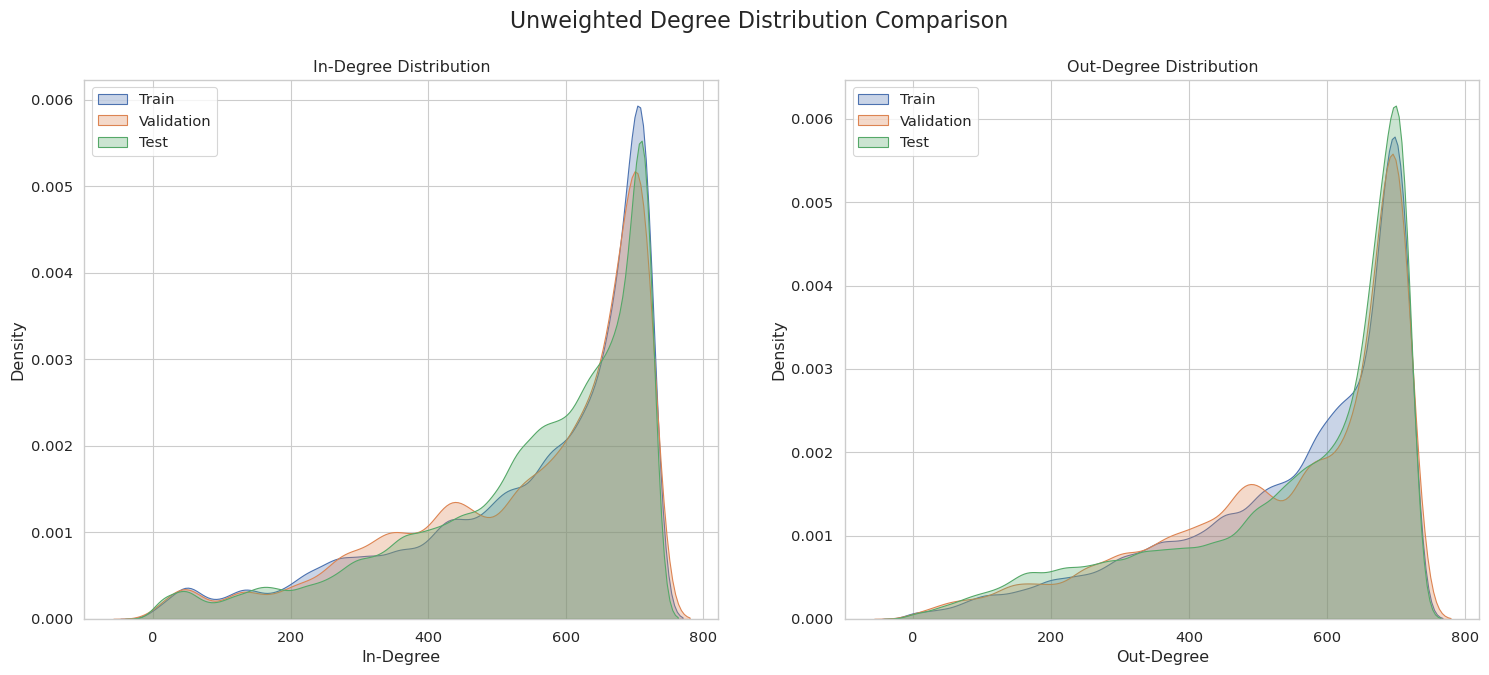

Figure saved to thesis_figures/NASDAQ/weighted_degree_distribution.pdf


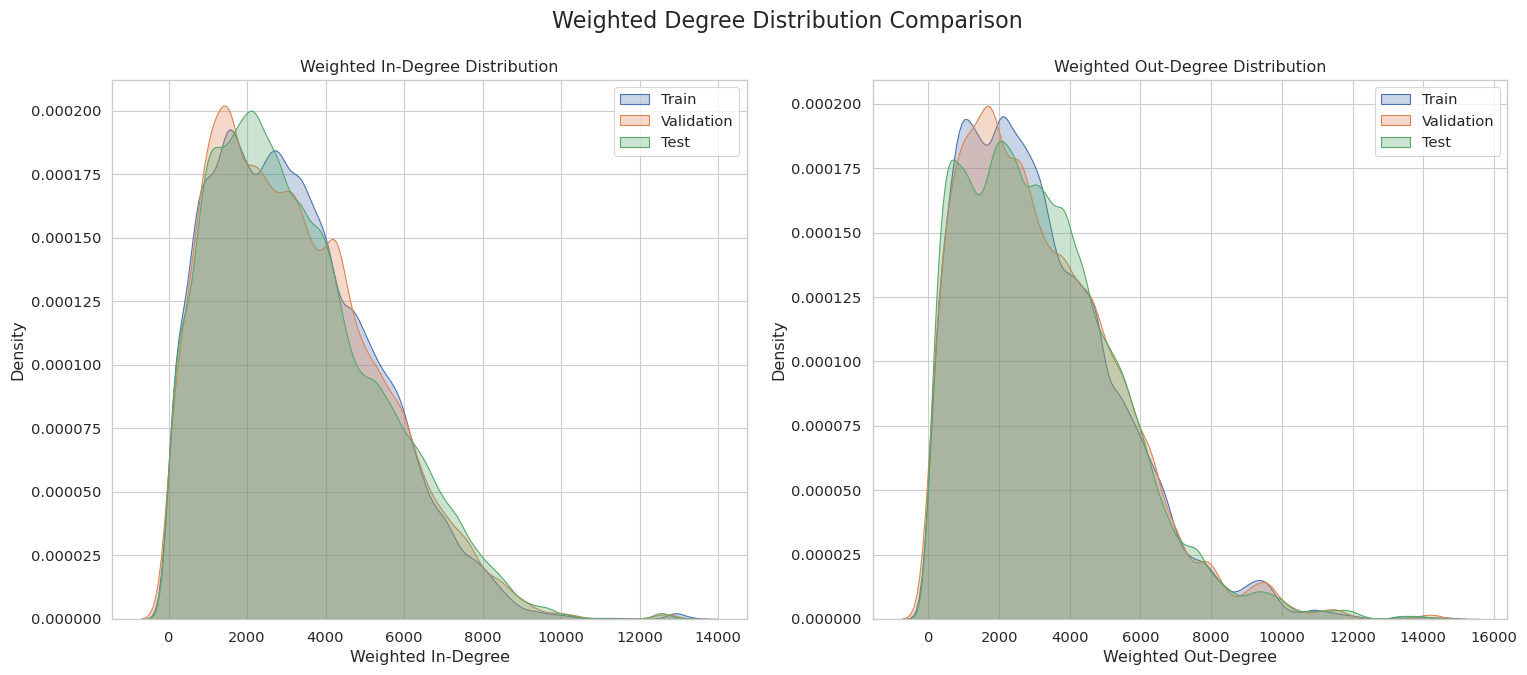

In [60]:
# --- Unweighted (Absolute) Degree Distribution ---
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Unweighted Degree Distribution Comparison', fontsize=16)

# In-Degree
for name, analyzer in analyzers.items():
    in_degrees, out_degrees, _, _ = analyzer.get_degree_dist()
    sns.kdeplot(in_degrees, ax=axes[0], label=name, fill=True, alpha=0.3)
axes[0].set_title('In-Degree Distribution')
axes[0].set_xlabel('In-Degree')
axes[0].set_ylabel('Density')
axes[0].legend()

# Out-Degree
for name, analyzer in analyzers.items():
    _, out_degrees, _, _ = analyzer.get_degree_dist()
    sns.kdeplot(out_degrees, ax=axes[1], label=name, fill=True, alpha=0.3)
axes[1].set_title('Out-Degree Distribution')
axes[1].set_xlabel('Out-Degree')
axes[1].legend()

save_figure('unweighted_degree_distribution')
plt.show()

# --- Weighted Degree Distribution ---
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Weighted Degree Distribution Comparison', fontsize=16)

# Weighted In-Degree
for name, analyzer in analyzers.items():
    _, _, weighted_in_degrees, _ = analyzer.get_degree_dist()
    sns.kdeplot(weighted_in_degrees, ax=axes[0], label=name, fill=True, alpha=0.3)
axes[0].set_title('Weighted In-Degree Distribution')
axes[0].set_xlabel('Weighted In-Degree')
axes[0].set_ylabel('Density')
axes[0].legend()

# Weighted Out-Degree
for name, analyzer in analyzers.items():
    _, _, _, weighted_out_degrees = analyzer.get_degree_dist()
    sns.kdeplot(weighted_out_degrees, ax=axes[1], label=name, fill=True, alpha=0.3)
axes[1].set_title('Weighted Out-Degree Distribution')
axes[1].set_xlabel('Weighted Out-Degree')
axes[1].legend()

save_figure('weighted_degree_distribution')
plt.show()


### 1.4. Connectivity Comparison

Figure saved to thesis_figures/NASDAQ/cross_dataset_connectivity.pdf


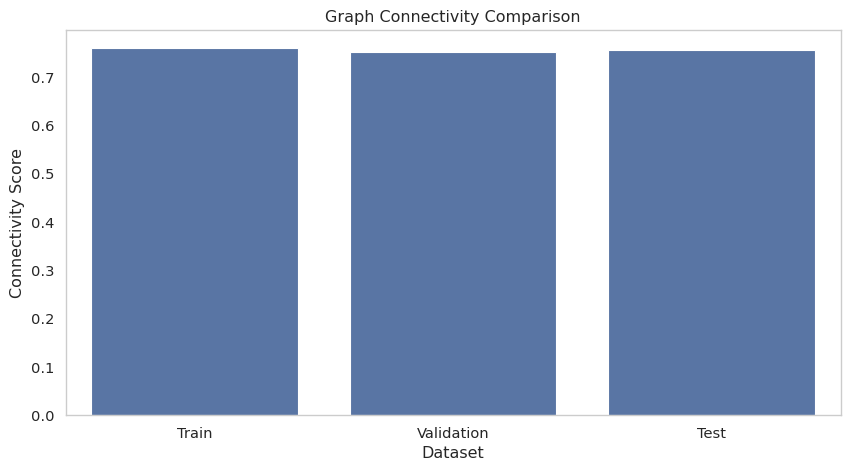

,Connectivity
Train,0.758894
Validation,0.751043
Test,0.754807


In [61]:
# Graph Connectivity Comparison
connectivity_scores = {name: analyzer.get_connectivity() for name, analyzer in analyzers.items()}
connectivity_df = pd.DataFrame.from_dict(connectivity_scores, orient='index', columns=['Connectivity'])

plt.figure(figsize=(10, 5))
sns.barplot(x=connectivity_df.index, y=connectivity_df['Connectivity'])
plt.title('Graph Connectivity Comparison')
plt.ylabel('Connectivity Score')
plt.xlabel('Dataset')
plt.grid(axis='y')
save_figure('cross_dataset_connectivity')
plt.show()

display(connectivity_df)

Figure saved to thesis_figures/NASDAQ/snapshot_adjacency_matrix_visualization.pdf


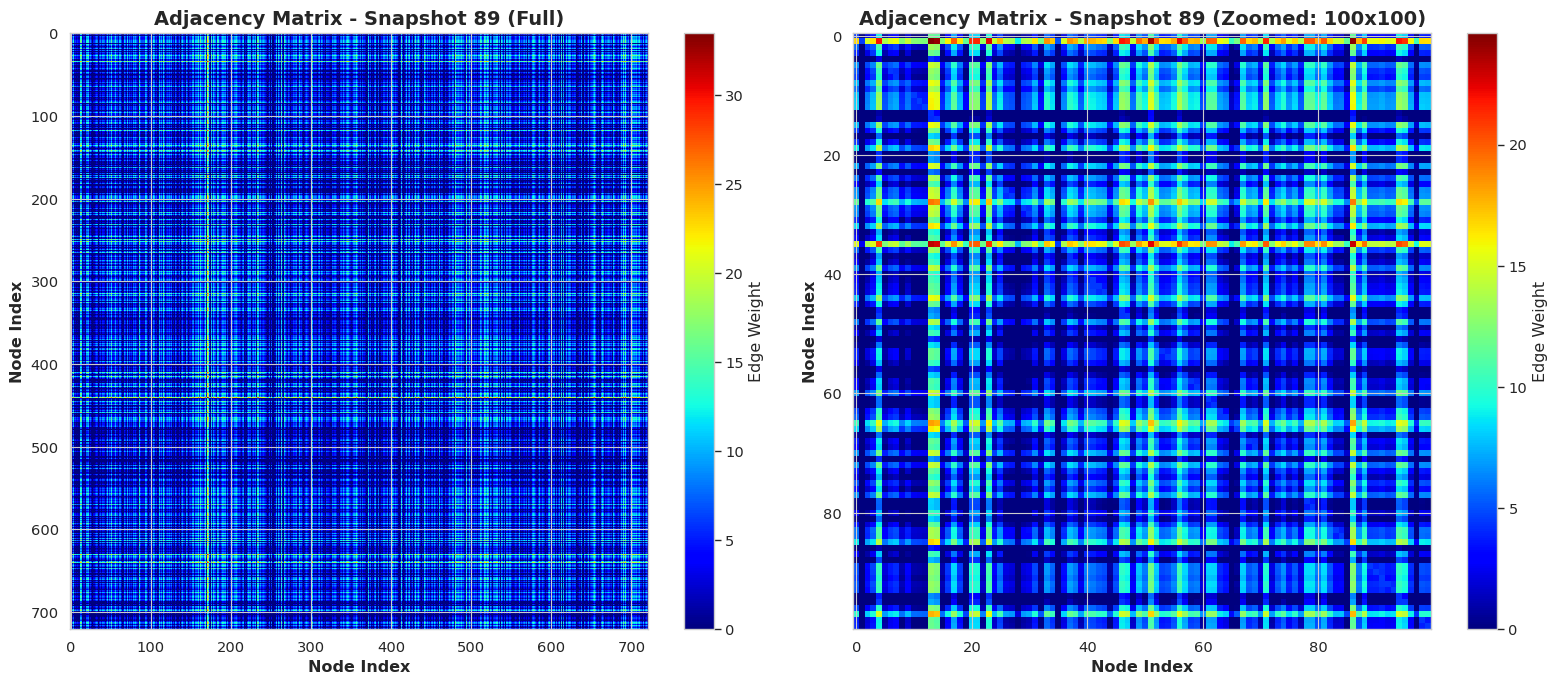


=== Snapshot 89 Statistics ===
Number of Nodes: 721
Number of Edges: 392538
Connectivity: 0.7562
Sparsity: 0.2438
Non-zero entries: 392538
Max edge weight: 33.4639
Mean edge weight (non-zero): 5.9906


In [62]:
# Visualize a Random Snapshot Adjacency Matrix
random_snapshot_idx = np.random.randint(0, train_analyzer.num_snapshots)
adj_matrix = train_adjs[random_snapshot_idx]

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Full adjacency matrix
im1 = axes[0].imshow(adj_matrix, cmap='jet', aspect='auto', interpolation='nearest')
axes[0].set_title(f'Adjacency Matrix - Snapshot {random_snapshot_idx} (Full)', fontweight='bold', fontsize=14)
axes[0].set_xlabel('Node Index', fontweight='bold')
axes[0].set_ylabel('Node Index', fontweight='bold')
plt.colorbar(im1, ax=axes[0], label='Edge Weight')

# Zoomed in view (first 100x100 nodes)
zoom_size = min(100, adj_matrix.shape[0])
adj_zoom = adj_matrix[:zoom_size, :zoom_size]
im2 = axes[1].imshow(adj_zoom, cmap='jet', aspect='auto', interpolation='nearest')
axes[1].set_title(f'Adjacency Matrix - Snapshot {random_snapshot_idx} (Zoomed: {zoom_size}x{zoom_size})', 
                  fontweight='bold', fontsize=14)
axes[1].set_xlabel('Node Index', fontweight='bold')
axes[1].set_ylabel('Node Index', fontweight='bold')
plt.colorbar(im2, ax=axes[1], label='Edge Weight')

plt.tight_layout()
save_figure('snapshot_adjacency_matrix_visualization')
plt.show()

# Print statistics about this snapshot
snapshot_info = train_analyzer.get_snapshot_info(random_snapshot_idx)
print(f"\n=== Snapshot {random_snapshot_idx} Statistics ===")
print(f"Number of Nodes: {snapshot_info['num_nodes']}")
print(f"Number of Edges: {snapshot_info['num_edges']}")
print(f"Connectivity: {snapshot_info['connectivity']:.4f}")
print(f"Sparsity: {1.0 - (snapshot_info['num_edges'] / (snapshot_info['num_nodes'] * (snapshot_info['num_nodes'] - 1))):.4f}")
print(f"Non-zero entries: {np.count_nonzero(adj_matrix)}")
print(f"Max edge weight: {np.max(adj_matrix):.4f}")
print(f"Mean edge weight (non-zero): {adj_matrix[adj_matrix > 0].mean():.4f}")

---
## 2. Feature Analysis

In [63]:
# Focus on training set for deep feature analysis
features_df = train_analyzer.analyze_node_features()

# Feature Statistics
feature_stats = features_df[train_analyzer.features].describe()
print("--- Feature Statistics (Training Set) ---")
display(feature_stats)

--- Feature Statistics (Training Set) ---


,Close,High,Low,Open,Volume
count,149968.000000,149968.000000,149968.000000,149968.000000,149968.000000
mean,0.647063,0.647072,0.647094,0.647212,0.352781
std,0.257331,0.257395,0.257399,0.257758,0.385765
min,-0.610874,-0.603349,-0.614386,-0.611282,-0.600062
25%,0.488963,0.488895,0.489366,0.489281,0.069976
50%,0.649679,0.649703,0.649373,0.649545,0.286488
75%,0.814252,0.814218,0.814445,0.814868,0.569508
max,1.963282,1.972878,1.949265,1.964577,2.819087


Figure saved to thesis_figures/NASDAQ/feature_distributions.pdf


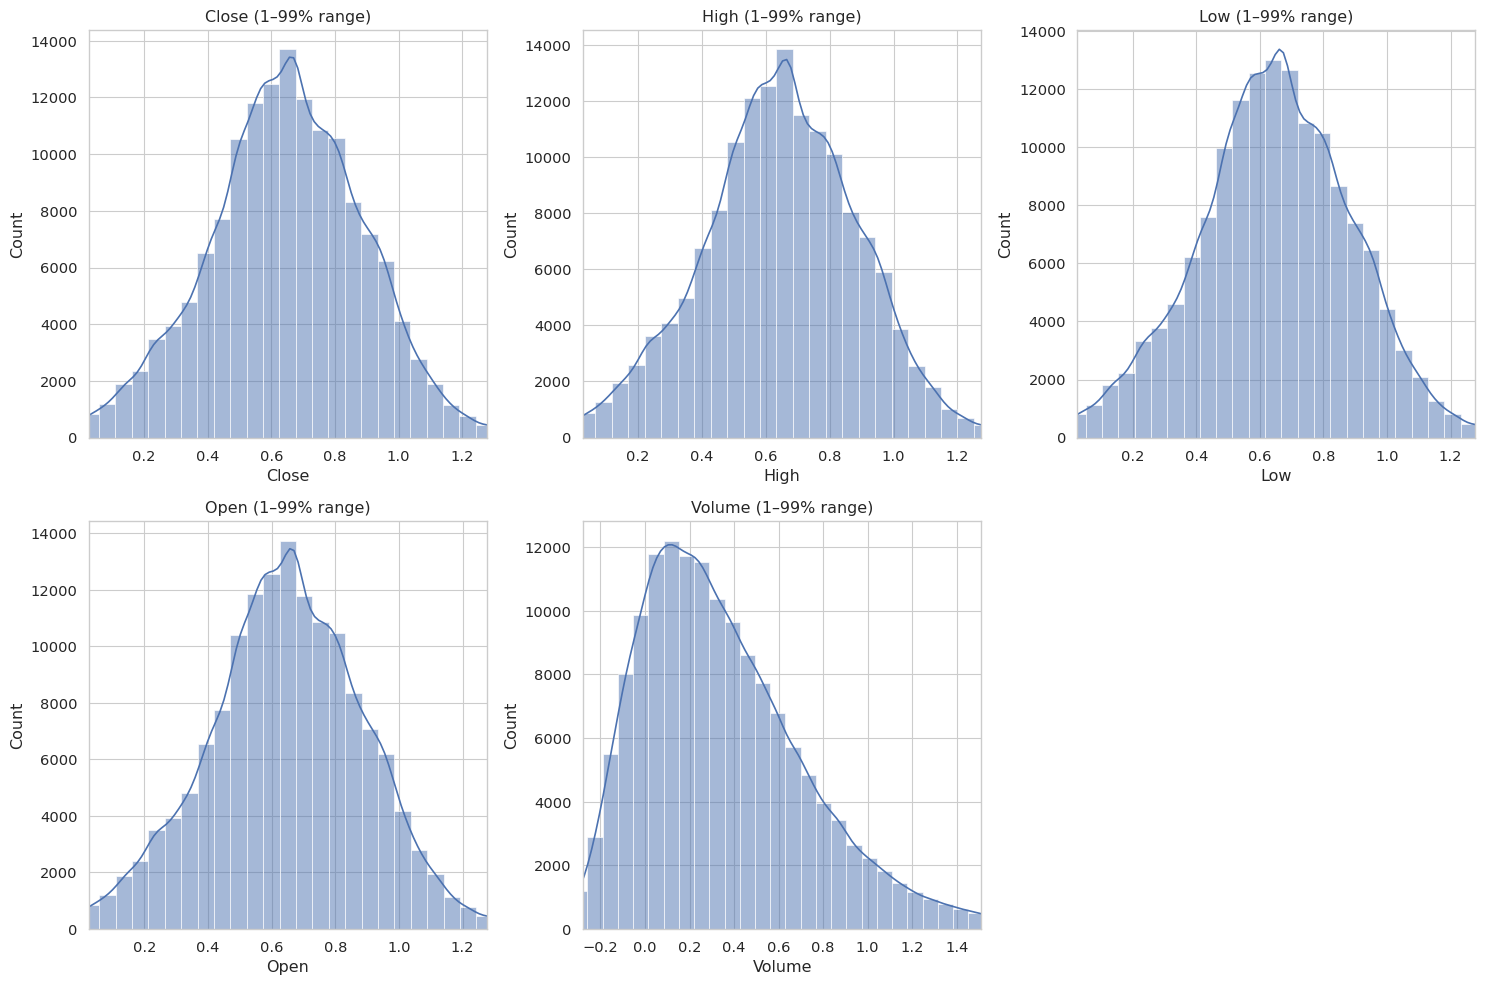

In [64]:
# Feature Distributions
plt.figure(figsize=(15, 10))

for i, feature in enumerate(train_analyzer.features):
    plt.subplot(2, 3, i + 1)
    sns.histplot(features_df[feature], kde=True, bins=50)
    q_low, q_high = features_df[feature].quantile([0.01, 0.99])
    plt.xlim(q_low, q_high)
    plt.title(f'{feature} (1–99% range)')
    
plt.tight_layout()
save_figure('feature_distributions')
plt.show()

Figure saved to thesis_figures/NASDAQ/feature_correlation_matrix.pdf


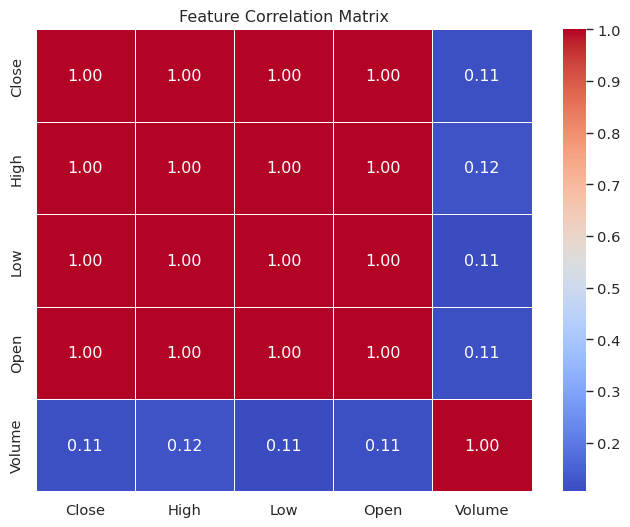

In [65]:
# Feature Correlation
correlation_matrix = features_df[train_analyzer.features].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Feature Correlation Matrix')
save_figure('feature_correlation_matrix')
plt.show()

Figure saved to thesis_figures/NASDAQ/feature_entropy.pdf


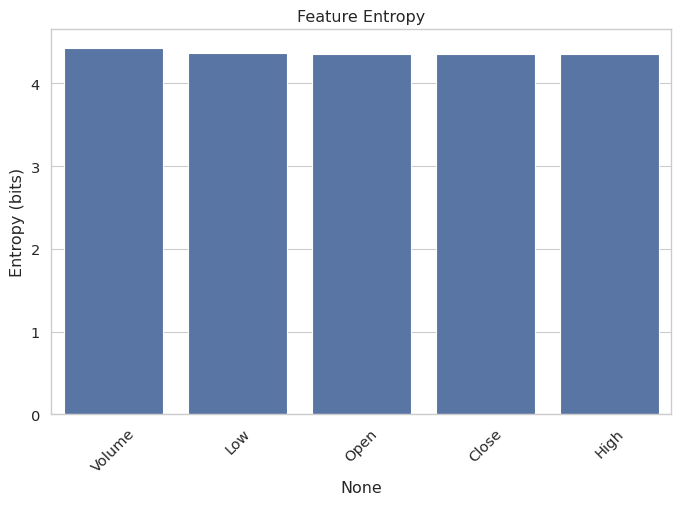

--- Feature Entropy ---


,Entropy
Volume,4.430006
Low,4.364273
Open,4.358897
Close,4.357083
High,4.357031


In [66]:
# Feature Entropy
def calculate_entropy(series, bins=50):
    """Calculates the entropy of a continuous series."""
    counts = np.histogram(series, bins=bins)[0]
    return entropy(counts, base=2)

feature_entropy = {feat: calculate_entropy(features_df[feat]) for feat in train_analyzer.features}
entropy_series = pd.Series(feature_entropy).sort_values(ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x=entropy_series.index, y=entropy_series.values)
plt.title('Feature Entropy')
plt.ylabel('Entropy (bits)')
plt.xticks(rotation=45)
save_figure('feature_entropy')
plt.show()

print("--- Feature Entropy ---")
display(entropy_series.to_frame('Entropy'))

---
## 3. Graph Topology Analysis

### 3.1. Homophily

Figure saved to thesis_figures/NASDAQ/cross_dataset_homophily.pdf


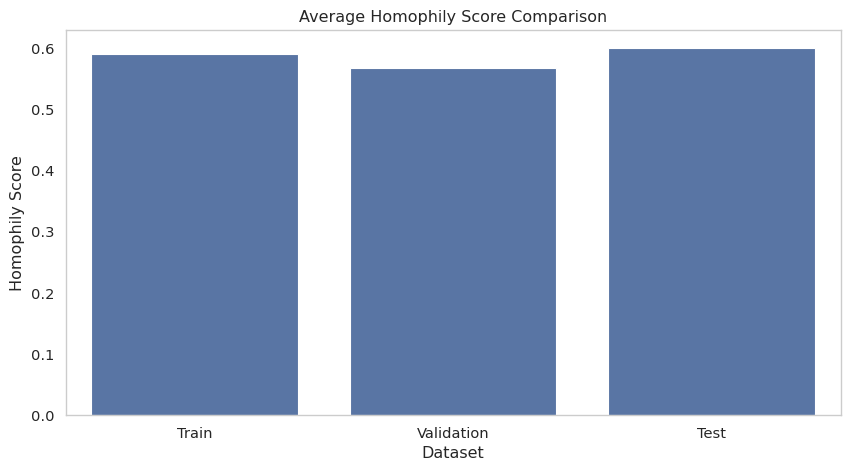

--- Average Homophily Scores ---


,Average Homophily
Train,0.590774
Validation,0.566743
Test,0.599590


In [67]:
# Compare Average Homophily Across Datasets
homophily_scores = {name: analyzer.get_average_homophily_score() for name, analyzer in analyzers.items()}
homophily_df = pd.DataFrame.from_dict(homophily_scores, orient='index', columns=['Average Homophily'])

plt.figure(figsize=(10, 5))
sns.barplot(x=homophily_df.index, y=homophily_df['Average Homophily'])
plt.title('Average Homophily Score Comparison')
plt.ylabel('Homophily Score')
plt.xlabel('Dataset')
plt.grid(axis='y')
save_figure('cross_dataset_homophily')
plt.show()

print("--- Average Homophily Scores ---")
display(homophily_df)

Figure saved to thesis_figures/NASDAQ/temporal_homophily_train.pdf


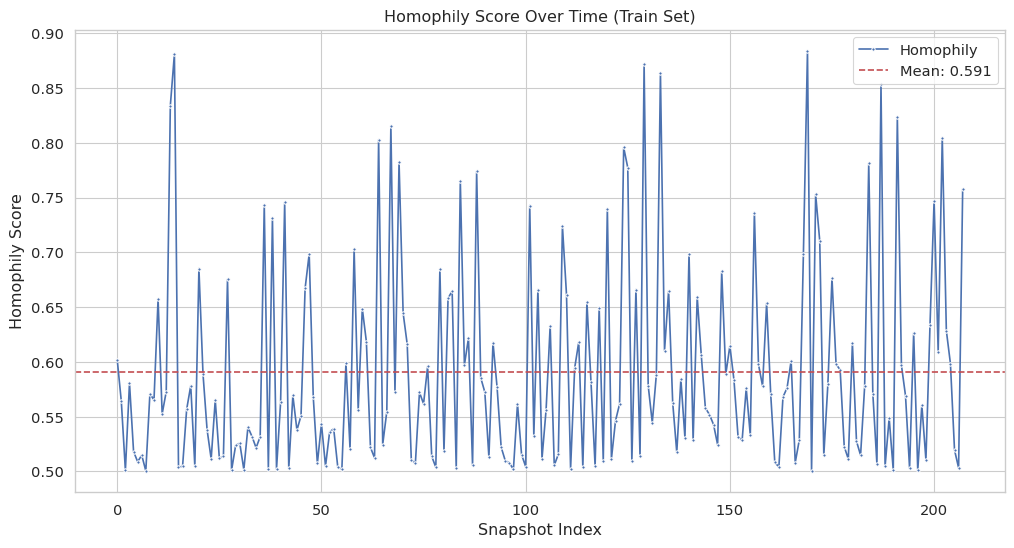

/tmp/ipykernel_3630630/1801966744.py:19: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


Figure saved to thesis_figures/NASDAQ/hist_homophily_train.pdf


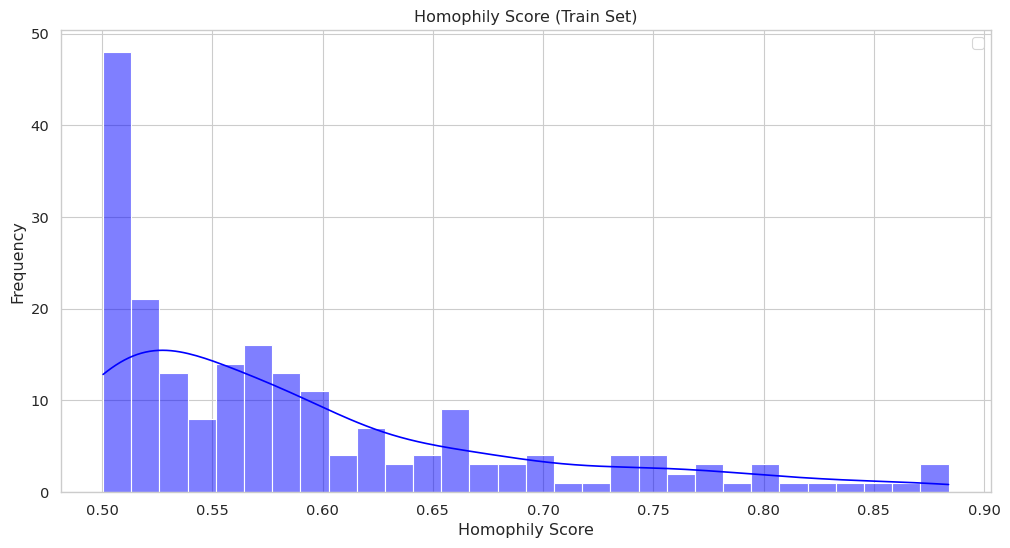

In [68]:
# Homophily Score Over Time (Train Set)
homophily_over_time = [train_analyzer.get_homophily_score(i) for i in range(train_analyzer.num_snapshots)]

plt.figure(figsize=(12, 6))
sns.lineplot(data=homophily_over_time, marker='.', linestyle='-', label='Homophily')
plt.axhline(y=np.mean(homophily_over_time), color='r', linestyle='--', label=f'Mean: {np.mean(homophily_over_time):.3f}')
plt.title('Homophily Score Over Time (Train Set)')
plt.xlabel('Snapshot Index')
plt.ylabel('Homophily Score')
plt.legend()
save_figure('temporal_homophily_train')
plt.show()

plt.figure(figsize=(12, 6))
sns.histplot(homophily_over_time, bins=30, kde=True, color='blue', alpha=0.5)
plt.title('Homophily Score (Train Set)')
plt.xlabel('Homophily Score')
plt.ylabel('Frequency')
plt.legend()
save_figure('hist_homophily_train')
plt.show()

### 3.2. Authorities and Hubs

In [69]:
# Calculate average degrees across all snapshots for train set
avg_degree_df_train = train_analyzer.get_average_node_degrees()

# Identify Top 10 Authorities (Highest In-Degree)
top_authorities_train = avg_degree_df_train.sort_values(by='avg_in_degree', ascending=False).head(10)
print("--- Top 10 Authorities (Highest In-Degree) - Train Set ---")
display(top_authorities_train[['ticker', 'avg_in_degree', 'avg_weighted_in_degree']])

# Identify Top 10 Hubs (Highest Out-Degree)
top_hubs_train = avg_degree_df_train.sort_values(by='avg_out_degree', ascending=False).head(10)
print("\n--- Top 10 Hubs (Highest Out-Degree) - Train Set ---")
display(top_hubs_train[['ticker', 'avg_out_degree', 'avg_weighted_out_degree']])

--- Top 10 Authorities (Highest In-Degree) - Train Set ---


,ticker,avg_in_degree,avg_weighted_in_degree
171,DWAQ,721.000000,12966.017578
172,DWPP,720.302885,9941.574219
169,DTYS,719.812500,9597.324219
263,HALL,719.605769,8500.919922
233,FTRI,719.552885,8377.029297
494,PLPC,719.461538,8343.611328
654,UG,719.355769,8019.476562
430,NKSH,719.331731,7746.894043
184,EMIF,719.288462,7818.693359
235,FUNC,719.225962,7723.539062



--- Top 10 Hubs (Highest Out-Degree) - Train Set ---


,ticker,avg_out_degree,avg_weighted_out_degree
441,NVDA,721.000000,13902.925781
1,AAPL,720.706731,11799.969727
35,AMZN,720.418269,10889.214844
640,TSLA,720.322115,11061.406250
631,TQQQ,720.173077,10216.033203
253,GOOGL,719.951923,9801.783203
416,MU,719.932692,9568.790039
252,GOOG,719.908654,9698.904297
411,MSFT,719.903846,9458.568359
143,CSX,719.764423,9532.808594


Figure saved to thesis_figures/NASDAQ/hubs_vs_authorities_train.pdf


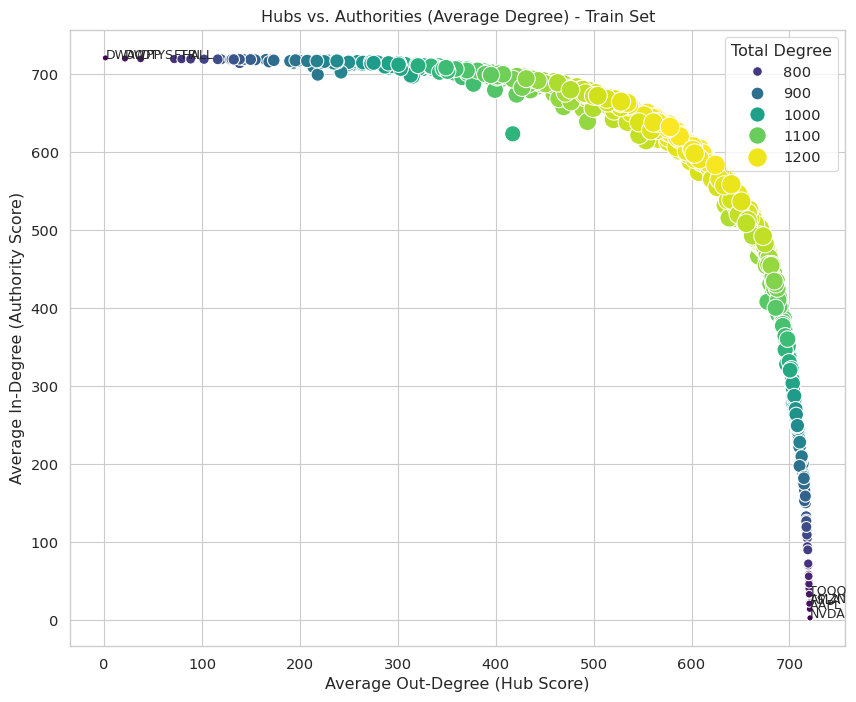

In [70]:
# Visualize Hubs vs Authorities
avg_degree_df_train['total_degree'] = avg_degree_df_train['avg_in_degree'] + avg_degree_df_train['avg_out_degree']

plt.figure(figsize=(10, 8))
sns.scatterplot(data=avg_degree_df_train, x='avg_out_degree', y='avg_in_degree', 
                size='total_degree', hue='total_degree', palette='viridis', sizes=(20, 200))

# Annotate top 5 hubs and authorities
for i, row in avg_degree_df_train.nlargest(5, 'avg_in_degree').iterrows():
    plt.text(row['avg_out_degree'], row['avg_in_degree'], row['ticker'], fontsize=9, ha='left')
for i, row in avg_degree_df_train.nlargest(5, 'avg_out_degree').iterrows():
    plt.text(row['avg_out_degree'], row['avg_in_degree'], row['ticker'], fontsize=9, ha='left')

plt.title('Hubs vs. Authorities (Average Degree) - Train Set')
plt.xlabel('Average Out-Degree (Hub Score)')
plt.ylabel('Average In-Degree (Authority Score)')
plt.legend(title='Total Degree')
save_figure('hubs_vs_authorities_train')
plt.show()

Figure saved to thesis_figures/NASDAQ/hubs_vs_authorities_weighted_test.pdf


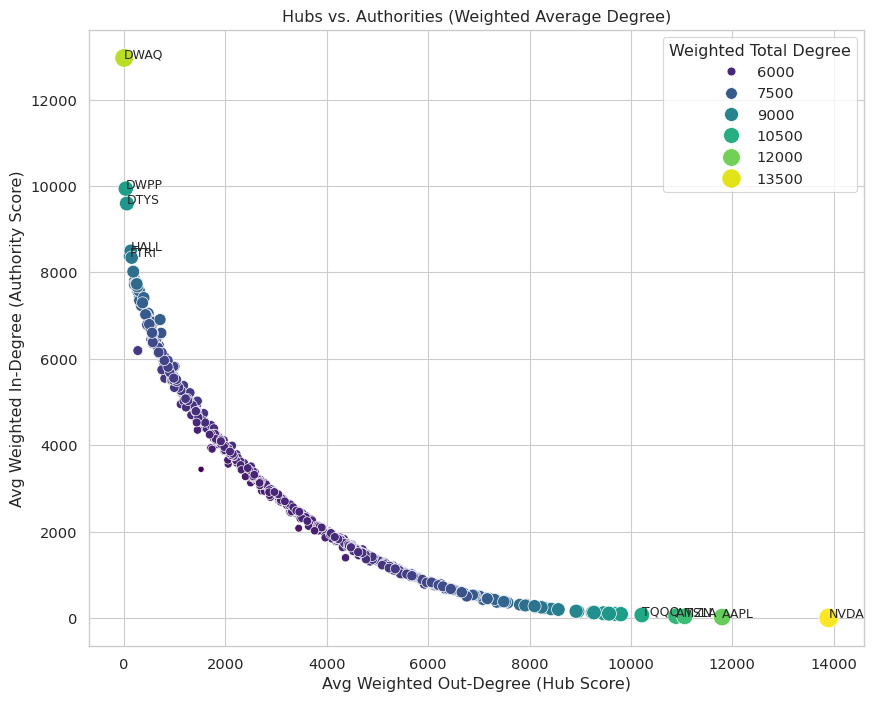

In [71]:
# --- Visualize Hubs vs Authorities (Weighted Degrees) ---
# Create a weighted total degree for sizing/coloring
avg_degree_df_train['weighted_total_degree'] = avg_degree_df_train['avg_weighted_in_degree'] + avg_degree_df_train['avg_weighted_out_degree']

plt.figure(figsize=(10, 8))
sns.scatterplot(
    data=avg_degree_df_train,
    x='avg_weighted_out_degree',
    y='avg_weighted_in_degree',
    size='weighted_total_degree',
    hue='weighted_total_degree',
    palette='viridis',
    sizes=(20, 200)
)

# Annotate top 5 weighted authorities and hubs
for _, row in avg_degree_df_train.nlargest(5, 'avg_weighted_in_degree').iterrows():
    plt.text(row['avg_weighted_out_degree'], row['avg_weighted_in_degree'], row['ticker'], fontsize=9, ha='left')
for _, row in avg_degree_df_train.nlargest(5, 'avg_weighted_out_degree').iterrows():
    plt.text(row['avg_weighted_out_degree'], row['avg_weighted_in_degree'], row['ticker'], fontsize=9, ha='left')

plt.title('Hubs vs. Authorities (Weighted Average Degree)')
plt.xlabel('Avg Weighted Out-Degree (Hub Score)')
plt.ylabel('Avg Weighted In-Degree (Authority Score)')
plt.legend(title='Weighted Total Degree')
save_figure('hubs_vs_authorities_weighted_test')
plt.show()

Figure saved to thesis_figures/NASDAQ/feature_correlation_matrix.pdf


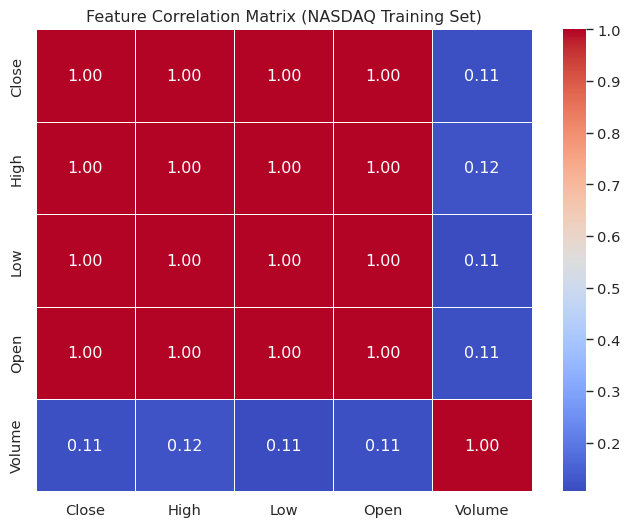


--- LaTeX Table: Feature Correlation Matrix ---
\begin{table}
\caption{Feature correlation matrix for NASDAQ training set.}
\label{tab:nasdaq_feature_correlation}
\begin{tabular}{lrrrrr}
\toprule
 & Close & High & Low & Open & Volume \\
\midrule
Close & 1.000 & 1.000 & 1.000 & 1.000 & 0.114 \\
High & 1.000 & 1.000 & 0.999 & 1.000 & 0.122 \\
Low & 1.000 & 0.999 & 1.000 & 1.000 & 0.105 \\
Open & 1.000 & 1.000 & 1.000 & 1.000 & 0.113 \\
Volume & 0.114 & 0.122 & 0.105 & 0.113 & 1.000 \\
\bottomrule
\end{tabular}
\end{table}



In [72]:
# Feature Correlation Matrix
features_df = train_analyzer.analyze_node_features()
correlation_matrix = features_df[train_analyzer.features].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Feature Correlation Matrix (NASDAQ Training Set)')
save_figure('feature_correlation_matrix')
plt.show()

# Save LaTeX table
print("\n--- LaTeX Table: Feature Correlation Matrix ---")
print(correlation_matrix.to_latex(caption='Feature correlation matrix for NASDAQ training set.', 
                                   label='tab:nasdaq_feature_correlation',
                                   float_format="%.3f"))

### 1.6. Feature Entropy Analysis

Feature entropy measures the predictability of a feature. Higher entropy implies less predictability and more information content.

Figure saved to thesis_figures/NASDAQ/feature_entropy.pdf


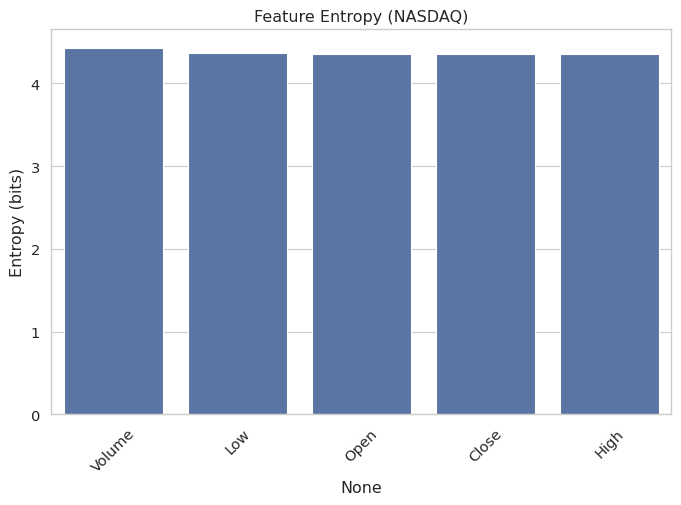

--- Feature Entropy ---


,Entropy
Volume,4.430006
Low,4.364273
Open,4.358897
Close,4.357083
High,4.357031



--- LaTeX Table: Feature Entropy ---
\begin{table}
\caption{Feature entropy for NASDAQ dataset.}
\label{tab:nasdaq_feature_entropy}
\begin{tabular}{lr}
\toprule
 & Entropy \\
\midrule
Volume & 4.430 \\
Low & 4.364 \\
Open & 4.359 \\
Close & 4.357 \\
High & 4.357 \\
\bottomrule
\end{tabular}
\end{table}



In [73]:
# Calculate entropy for each feature
def calculate_entropy(series, bins=50):
    """Calculates the entropy of a continuous series."""
    counts = np.histogram(series, bins=bins)[0]
    return entropy(counts, base=2)

feature_entropy = {feat: calculate_entropy(features_df[feat]) for feat in train_analyzer.features}
entropy_series = pd.Series(feature_entropy).sort_values(ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x=entropy_series.index, y=entropy_series.values)
plt.title('Feature Entropy (NASDAQ)')
plt.ylabel('Entropy (bits)')
plt.xticks(rotation=45)
save_figure('feature_entropy')
plt.show()

print("--- Feature Entropy ---")
display(entropy_series.to_frame('Entropy'))

# Save LaTeX table
print("\n--- LaTeX Table: Feature Entropy ---")
print(entropy_series.to_frame('Entropy').to_latex(caption='Feature entropy for NASDAQ dataset.',
                                                   label='tab:nasdaq_feature_entropy',
                                                   float_format="%.3f"))

### 1.5. Feature Correlation Matrix

A correlation matrix reveals linear relationships between features, helping identify redundancy and multicollinearity.

In [74]:
# Calculate average degrees for test set
avg_degree_df_test = test_analyzer.get_average_node_degrees()

# Identify Top 10 Authorities (Test Set)
top_authorities_test = avg_degree_df_test.sort_values(by='avg_in_degree', ascending=False).head(10)
print("--- Top 10 Authorities (Highest In-Degree) - Test Set ---")
display(top_authorities_test[['ticker', 'avg_in_degree', 'avg_weighted_in_degree']])

# Identify Top 10 Hubs (Test Set)
top_hubs_test = avg_degree_df_test.sort_values(by='avg_out_degree', ascending=False).head(10)
print("\n--- Top 10 Hubs (Highest Out-Degree) - Test Set ---")
display(top_hubs_test[['ticker', 'avg_out_degree', 'avg_weighted_out_degree']])

--- Top 10 Authorities (Highest In-Degree) - Test Set ---


,ticker,avg_in_degree,avg_weighted_in_degree
171,DWAQ,721.000000,12632.458008
169,DTYS,720.123989,9656.801758
654,UG,719.878706,8510.911133
233,FTRI,719.811321,8968.320312
101,CFFI,719.485175,7945.642090
703,WINA,719.458221,8106.020996
162,DLBS,719.366577,8162.873535
184,EMIF,719.342318,8137.935547
302,IFEU,719.291105,8241.723633
413,MTEX,719.080863,8075.493164



--- Top 10 Hubs (Highest Out-Degree) - Test Set ---


,ticker,avg_out_degree,avg_weighted_out_degree
441,NVDA,721.000000,13705.408203
1,AAPL,720.978437,11678.457031
35,AMZN,720.902965,11272.557617
640,TSLA,720.838275,11841.625000
631,TQQQ,720.355795,10800.199219
253,GOOGL,720.016173,9935.757812
252,GOOG,719.975741,9754.570312
543,QQQ,719.964960,9971.885742
416,MU,719.843666,9837.598633
411,MSFT,719.776280,9531.351562


Figure saved to thesis_figures/NASDAQ/hubs_vs_authorities_test.pdf


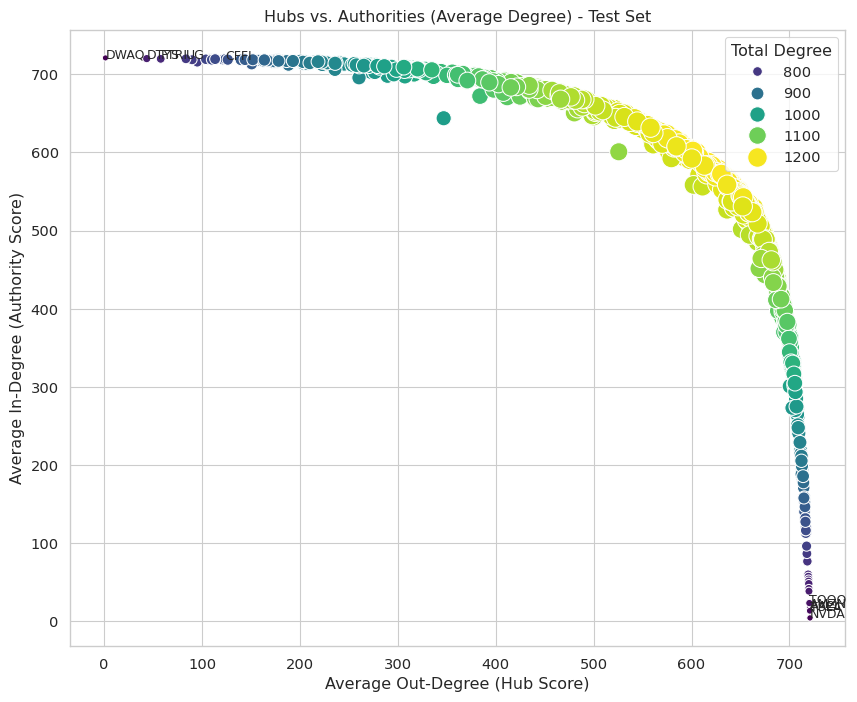

In [75]:
# Visualize Hubs vs Authorities (Test Set)
avg_degree_df_test['total_degree'] = avg_degree_df_test['avg_in_degree'] + avg_degree_df_test['avg_out_degree']

plt.figure(figsize=(10, 8))
sns.scatterplot(data=avg_degree_df_test, x='avg_out_degree', y='avg_in_degree', 
                size='total_degree', hue='total_degree', palette='viridis', sizes=(20, 200))

for i, row in avg_degree_df_test.nlargest(5, 'avg_in_degree').iterrows():
    plt.text(row['avg_out_degree'], row['avg_in_degree'], row['ticker'], fontsize=9, ha='left')
for i, row in avg_degree_df_test.nlargest(5, 'avg_out_degree').iterrows():
    plt.text(row['avg_out_degree'], row['avg_in_degree'], row['ticker'], fontsize=9, ha='left')

plt.title('Hubs vs. Authorities (Average Degree) - Test Set')
plt.xlabel('Average Out-Degree (Hub Score)')
plt.ylabel('Average In-Degree (Authority Score)')
plt.legend(title='Total Degree')
save_figure('hubs_vs_authorities_test')
plt.show()

Figure saved to thesis_figures/NASDAQ/hubs_vs_authorities_weighted_test.pdf


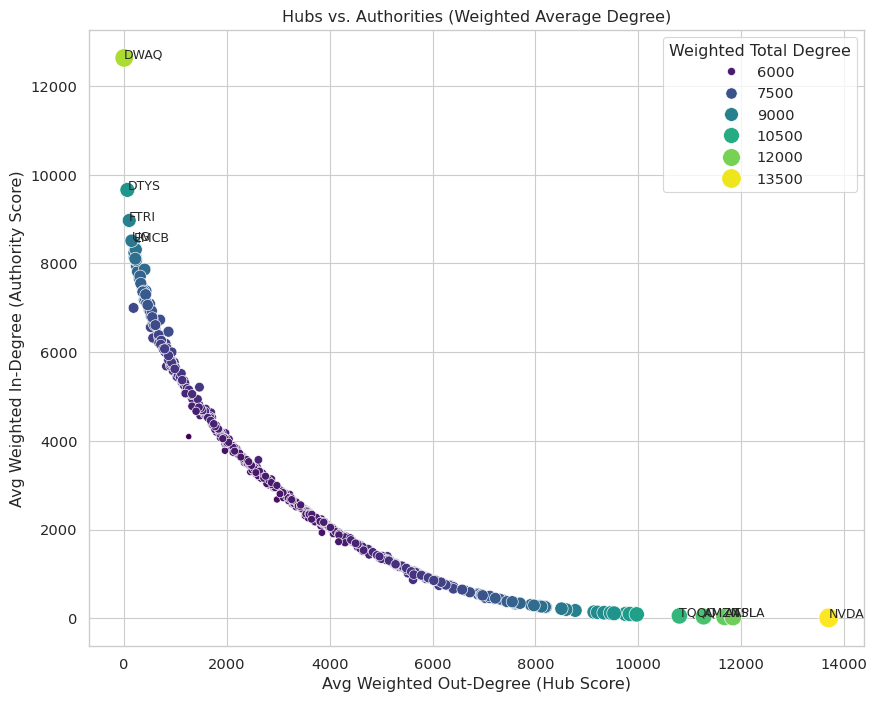

In [76]:
# --- Visualize Hubs vs Authorities (Weighted Degrees) ---
# Create a weighted total degree for sizing/coloring
avg_degree_df_test['weighted_total_degree'] = avg_degree_df_test['avg_weighted_in_degree'] + avg_degree_df_test['avg_weighted_out_degree']

plt.figure(figsize=(10, 8))
sns.scatterplot(
    data=avg_degree_df_test,
    x='avg_weighted_out_degree',
    y='avg_weighted_in_degree',
    size='weighted_total_degree',
    hue='weighted_total_degree',
    palette='viridis',
    sizes=(20, 200)
)

# Annotate top 5 weighted authorities and hubs
for _, row in avg_degree_df_test.nlargest(5, 'avg_weighted_in_degree').iterrows():
    plt.text(row['avg_weighted_out_degree'], row['avg_weighted_in_degree'], row['ticker'], fontsize=9, ha='left')
for _, row in avg_degree_df_test.nlargest(5, 'avg_weighted_out_degree').iterrows():
    plt.text(row['avg_weighted_out_degree'], row['avg_weighted_in_degree'], row['ticker'], fontsize=9, ha='left')

plt.title('Hubs vs. Authorities (Weighted Average Degree)')
plt.xlabel('Avg Weighted Out-Degree (Hub Score)')
plt.ylabel('Avg Weighted In-Degree (Authority Score)')
plt.legend(title='Weighted Total Degree')
save_figure('hubs_vs_authorities_weighted_test')
plt.show()

### 3.3. Centrality

In [77]:
# Multi-snapshot centrality averaging
# Select snapshots for centrality analysis (evenly spaced)
NUM_SNAPSHOTS_CENTRALITY = 10
snapshot_indices = np.linspace(0, train_analyzer.num_snapshots - 1, NUM_SNAPSHOTS_CENTRALITY, dtype=int)

print(f"Computing centrality across {NUM_SNAPSHOTS_CENTRALITY} snapshots...")
print(f"Snapshot indices: {snapshot_indices}")

# Initialize storage for centrality values
degree_centralities = []
eigenvector_centralities = []
betweenness_centralities = []

for idx in snapshot_indices:
    print(f"Processing snapshot {idx}...", end='\r')
    G = nx.from_numpy_array(train_adjs[idx], create_using=nx.DiGraph)
    
    degree_centralities.append(nx.degree_centrality(G))
    eigenvector_centralities.append(nx.eigenvector_centrality(G, weight='weight', max_iter=1000))
    betweenness_centralities.append(nx.betweenness_centrality(G, weight='weight', k=100))  # Approximate with k=100

print("\nCentrality computation complete!")

# Average centralities across snapshots
avg_degree_centrality = pd.DataFrame(degree_centralities).mean()
avg_eigenvector_centrality = pd.DataFrame(eigenvector_centralities).mean()
avg_betweenness_centrality = pd.DataFrame(betweenness_centralities).mean()

centrality_df = pd.DataFrame({
    'Degree': avg_degree_centrality,
    'Eigenvector': avg_eigenvector_centrality,
    'Betweenness': avg_betweenness_centrality
})

print("\n--- Top 10 Nodes by Average Centrality Measures ---")
for col in centrality_df.columns:
    print(f"\n--- Top 10 by {col} Centrality ---")
    top_nodes = centrality_df[col].nlargest(10)
    top_nodes.index = [train_analyzer.index_to_stock[i] for i in top_nodes.index]
    display(top_nodes)

Computing centrality across 10 snapshots...
Snapshot indices: [  0  23  46  69  92 115 138 161 184 207]


Processing snapshot 207...
Centrality computation complete!

--- Top 10 Nodes by Average Centrality Measures ---

--- Top 10 by Degree Centrality ---


KALU    1.683889
MKTX    1.682778
RNST    1.682361
UMBF    1.682083
VGIT    1.681528
ARCB    1.680278
IGOV    1.679722
CASH    1.679444
FFBC    1.679028
BOKF    1.678889
Name: Degree, dtype: float64


--- Top 10 by Eigenvector Centrality ---


DWAQ    0.190845
DTYS    0.129782
DWPP    0.128089
PLPC    0.112262
HALL    0.108292
FTRI    0.106845
UG      0.103663
OFLX    0.098854
FUNC    0.098390
NKSH    0.098347
Name: Eigenvector, dtype: float64


--- Top 10 by Betweenness Centrality ---


SHV     0.033589
SIR     0.022494
PLAB    0.017622
STAA    0.015564
VGSH    0.010031
RDI     0.009457
KVHI    0.008648
VMBS    0.008507
VTIP    0.008383
KTCC    0.008017
Name: Betweenness, dtype: float64

Figure saved to thesis_figures/NASDAQ/centrality_distributions_averaged.pdf


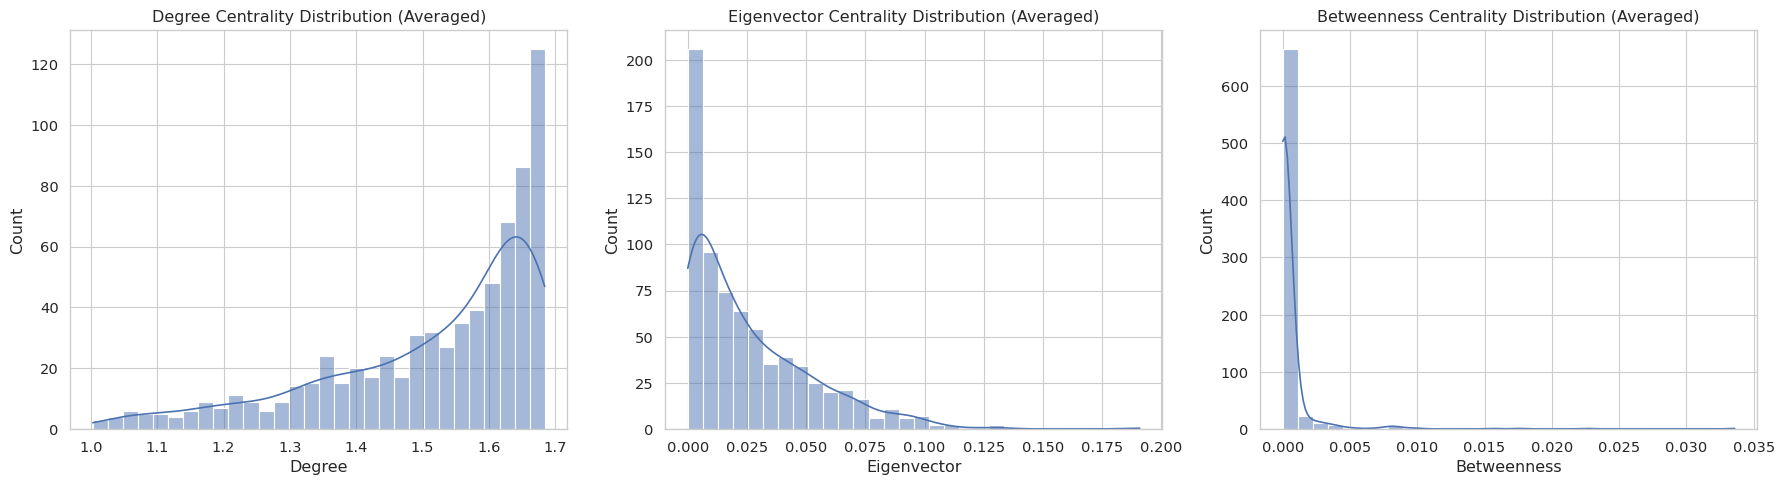

In [78]:
# Plotting Centrality Distributions
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, col in enumerate(centrality_df.columns):
    sns.histplot(centrality_df[col], ax=axes[i], kde=True, bins=30)
    axes[i].set_title(f'{col} Centrality Distribution (Averaged)')
plt.tight_layout()
save_figure('centrality_distributions_averaged')
plt.show()

### 3.4. Subgraph Visualization with Target Labels

To better understand the relationship between graph structure and stock movements, we visualize a subgraph containing the most central nodes. Nodes are color-coded by their target prediction label: **green** indicates an upward price movement (target = 1), while **red** indicates a downward movement (target = 0).

This visualization helps us identify patterns such as:
- Whether highly central stocks tend to move together
- The presence of homophilous or heterophilous connections
- Local clustering of stocks with similar price movements

Figure saved to thesis_figures/NASDAQ/subgraph_target_visualization_snapshot_10.pdf


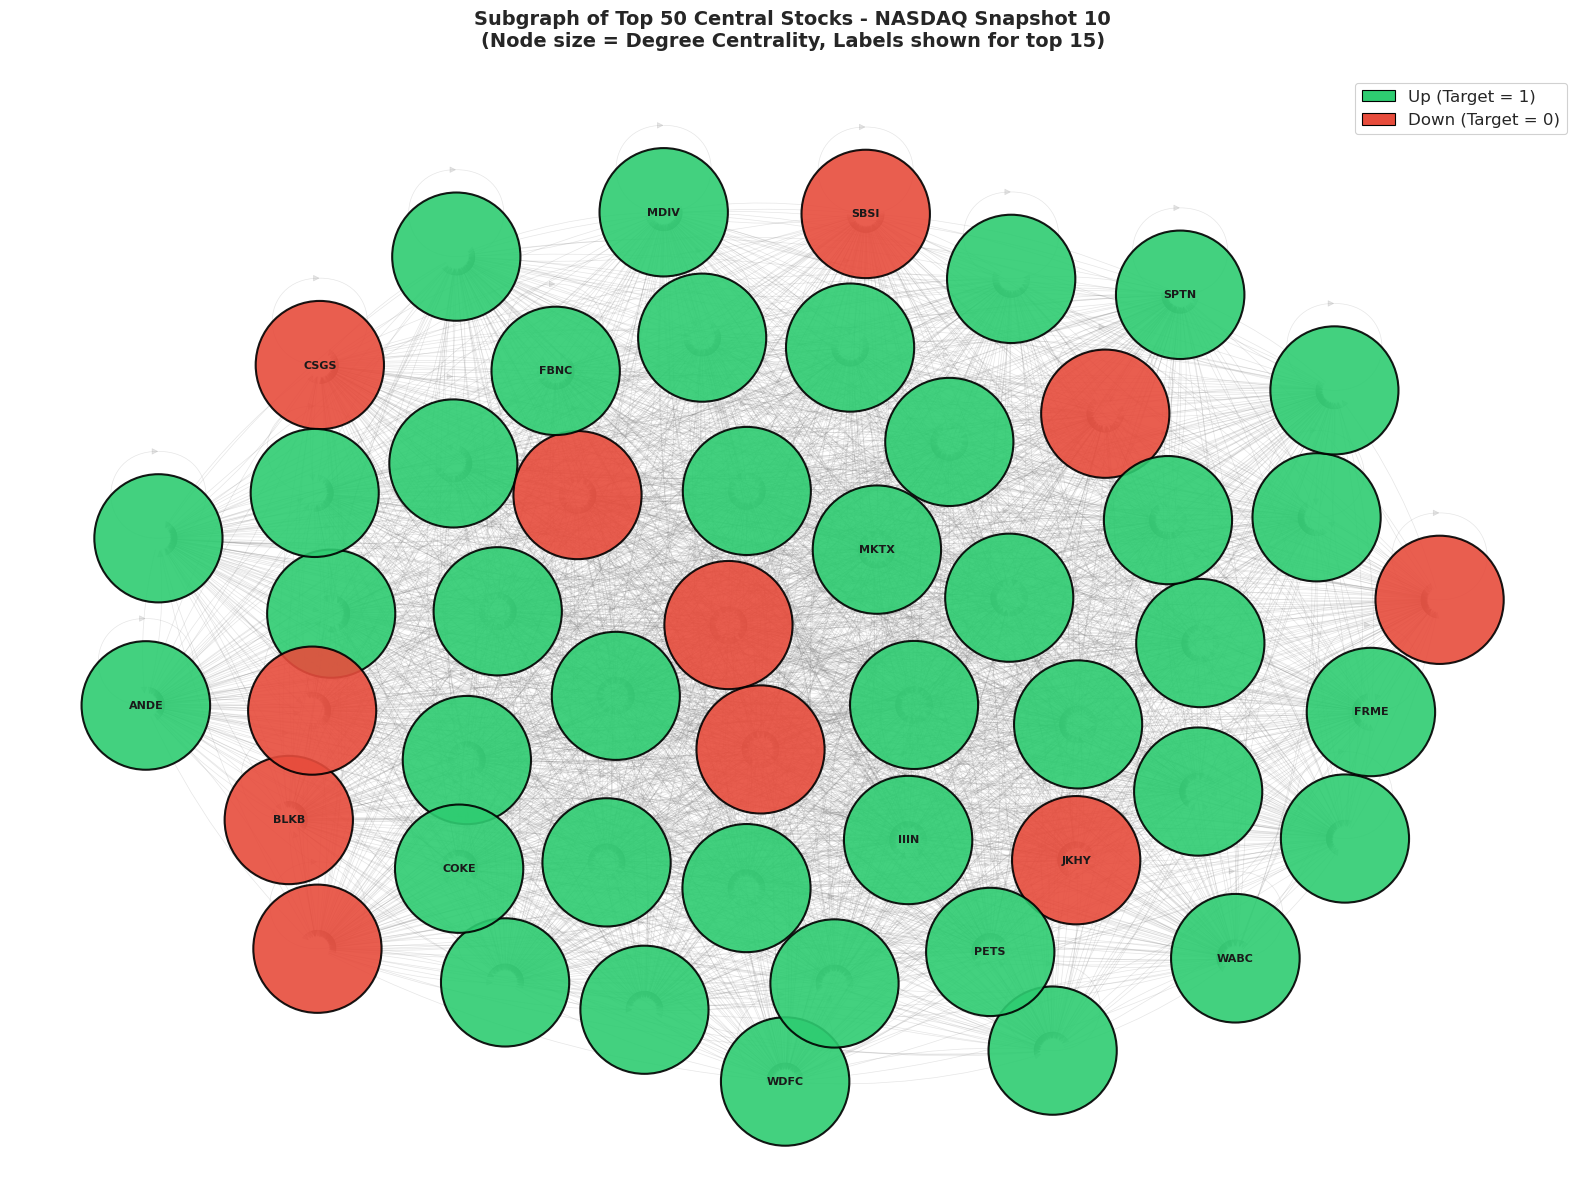


Subgraph Statistics (NASDAQ Snapshot 10):
Total nodes in subgraph: 50
Total edges in subgraph: 2500
Up stocks (green): 39 (78.0%)
Down stocks (red): 11 (22.0%)
Average clustering coefficient: 1.0000
Graph density: 1.0204



In [79]:
# Select a snapshot for visualization
SNAPSHOT_IDX = 10
TOP_N_NODES = 50  # Number of most central nodes to visualize

# Get adjacency matrix and create graph
adj = train_adjs[SNAPSHOT_IDX]
G_full = nx.from_numpy_array(adj, create_using=nx.DiGraph)

# Get target labels for this snapshot
snapshot_data = train_analyzer.graph_snapshots[SNAPSHOT_IDX]
targets = snapshot_data.y.numpy()

# Calculate degree centrality to select top nodes
degree_cent = nx.degree_centrality(G_full)
top_nodes = sorted(degree_cent, key=degree_cent.get, reverse=True)[:TOP_N_NODES]

# Create subgraph with only top central nodes
G_sub = G_full.subgraph(top_nodes).copy()

# Map node colors based on target (Up=Green, Down=Red)
node_colors = ['#2ecc71' if targets[node] == 1 else '#e74c3c' for node in G_sub.nodes()]
node_labels = {node: train_analyzer.index_to_stock[node] for node in G_sub.nodes()}

# Calculate node sizes based on centrality
node_sizes = [degree_cent[node] * 5000 for node in G_sub.nodes()]

# Create the visualization
plt.figure(figsize=(16, 12))

# Use spring layout for better visualization
pos = nx.spring_layout(G_sub, k=2, iterations=50, seed=42)

# Draw the graph
nx.draw_networkx_edges(G_sub, pos, alpha=0.2, edge_color='gray', 
                       arrows=True, arrowsize=10, width=0.5,
                       connectionstyle='arc3,rad=0.1')

nx.draw_networkx_nodes(G_sub, pos, 
                       node_color=node_colors,
                       node_size=node_sizes,
                       alpha=0.9,
                       edgecolors='black',
                       linewidths=1.5)

# Add labels for top 15 nodes
top_15_nodes = top_nodes[:15]
labels_subset = {node: node_labels[node] for node in top_15_nodes if node in G_sub.nodes()}
nx.draw_networkx_labels(G_sub, pos, labels_subset, font_size=8, font_weight='bold')

# Add legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#2ecc71', edgecolor='black', label='Up (Target = 1)'),
    Patch(facecolor='#e74c3c', edgecolor='black', label='Down (Target = 0)')
]
plt.legend(handles=legend_elements, loc='upper right', fontsize=12, framealpha=0.9)

plt.title(f'Subgraph of Top {TOP_N_NODES} Central Stocks - NASDAQ Snapshot {SNAPSHOT_IDX}\n'
          f'(Node size = Degree Centrality, Labels shown for top 15)', 
          fontsize=14, fontweight='bold', pad=20)
plt.axis('off')
plt.tight_layout()
save_figure(f'subgraph_target_visualization_snapshot_{SNAPSHOT_IDX}')
plt.show()

# Print statistics
up_count = sum(1 for node in G_sub.nodes() if targets[node] == 1)
down_count = len(G_sub.nodes()) - up_count
print(f"\n{'='*60}")
print(f"Subgraph Statistics (NASDAQ Snapshot {SNAPSHOT_IDX}):")
print(f"{'='*60}")
print(f"Total nodes in subgraph: {len(G_sub.nodes())}")
print(f"Total edges in subgraph: {len(G_sub.edges())}")
print(f"Up stocks (green): {up_count} ({up_count/len(G_sub.nodes())*100:.1f}%)")
print(f"Down stocks (red): {down_count} ({down_count/len(G_sub.nodes())*100:.1f}%)")
print(f"Average clustering coefficient: {nx.average_clustering(G_sub):.4f}")
print(f"Graph density: {nx.density(G_sub):.4f}")
print(f"{'='*60}\n")

Figure saved to thesis_figures/NASDAQ/subgraph_circular_layout_snapshot_10.pdf


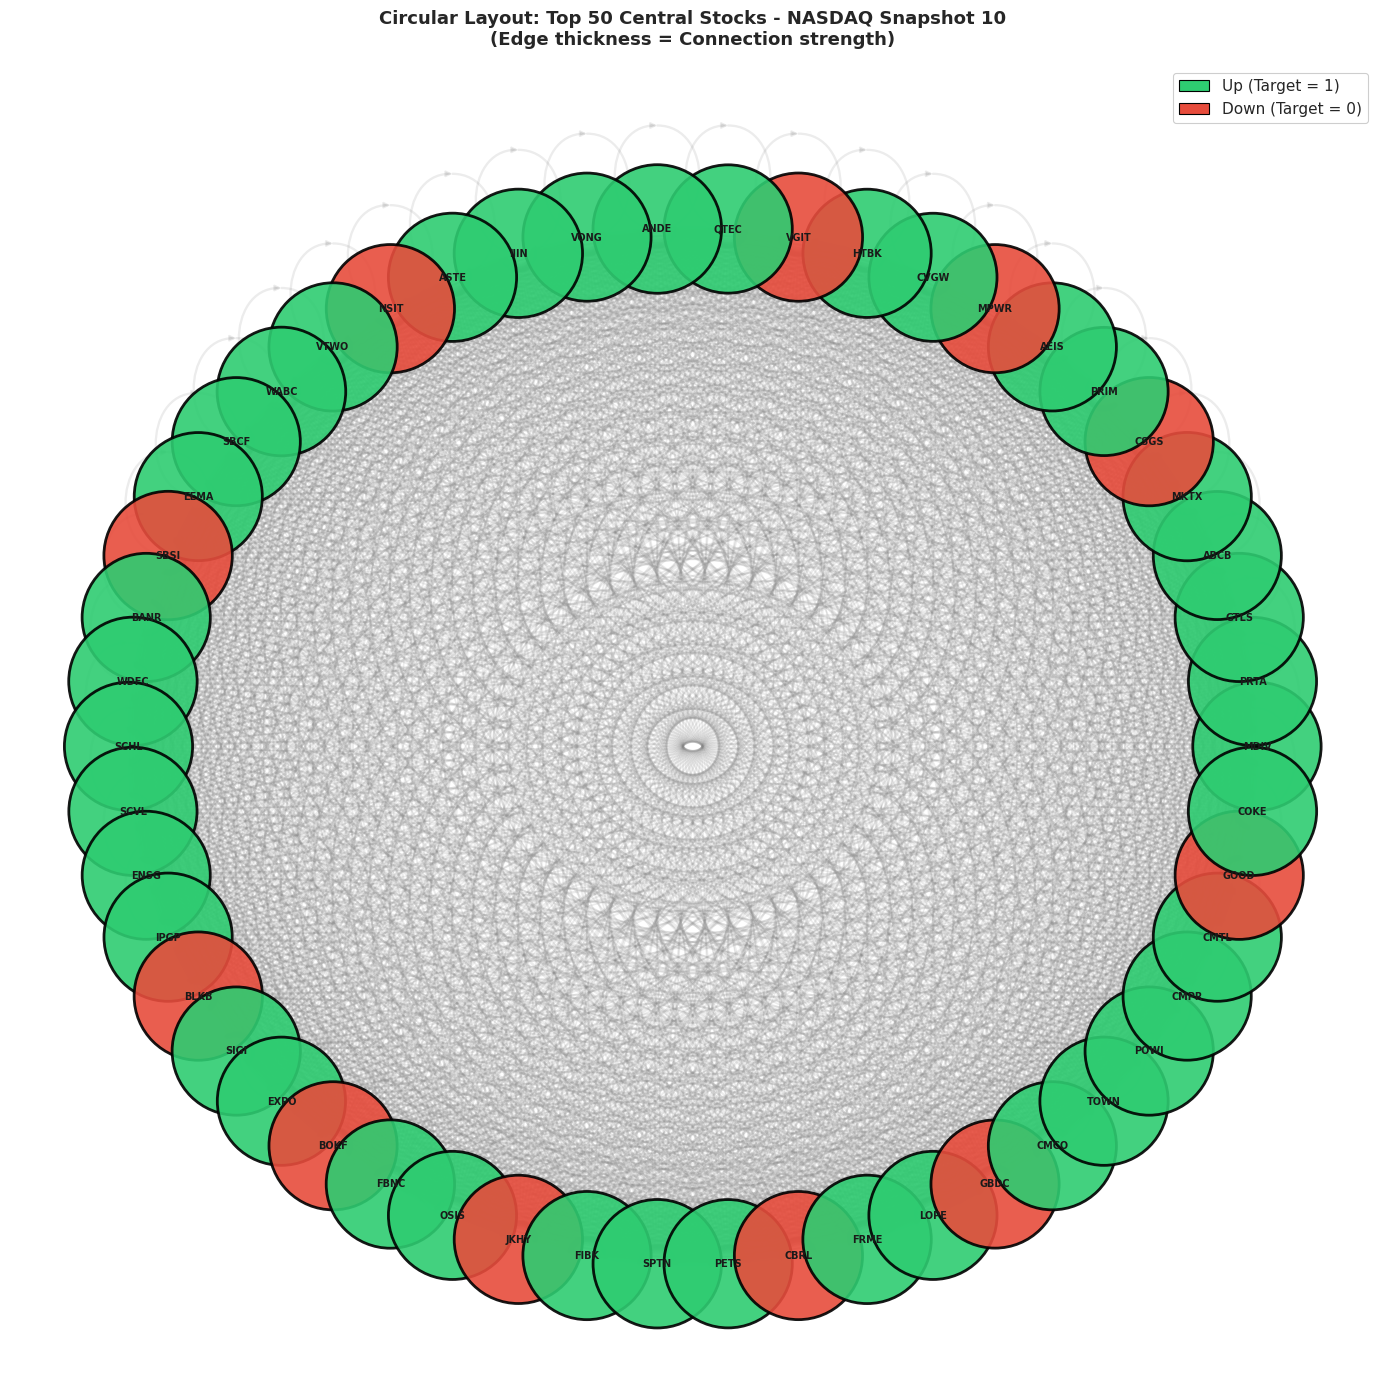

In [80]:
# Circular layout visualization (alternative)
plt.figure(figsize=(14, 14))

# Use circular layout
pos_circular = nx.circular_layout(G_sub)

# Draw edges with varying thickness based on weight
edges = G_sub.edges()
weights = [G_sub[u][v].get('weight', 1) for u, v in edges]
max_weight = max(weights) if weights else 1
edge_widths = [w / max_weight * 2 for w in weights]

nx.draw_networkx_edges(G_sub, pos_circular, 
                       alpha=0.15, 
                       edge_color='gray',
                       width=edge_widths,
                       arrows=True, 
                       arrowsize=8,
                       connectionstyle='arc3,rad=0.05')

nx.draw_networkx_nodes(G_sub, pos_circular,
                       node_color=node_colors,
                       node_size=node_sizes,
                       alpha=0.9,
                       edgecolors='black',
                       linewidths=2)

# Add all labels in circular layout for better readability
nx.draw_networkx_labels(G_sub, pos_circular, node_labels, 
                       font_size=7, font_weight='bold')

# Legend
plt.legend(handles=legend_elements, loc='upper right', fontsize=11, framealpha=0.95)

plt.title(f'Circular Layout: Top {TOP_N_NODES} Central Stocks - NASDAQ Snapshot {SNAPSHOT_IDX}\n'
          f'(Edge thickness = Connection strength)', 
          fontsize=13, fontweight='bold', pad=15)
plt.axis('off')
plt.tight_layout()
save_figure(f'subgraph_circular_layout_snapshot_{SNAPSHOT_IDX}')
plt.show()

Figure saved to thesis_figures/NASDAQ/subgraph_homophily_analysis_snapshot_10.pdf


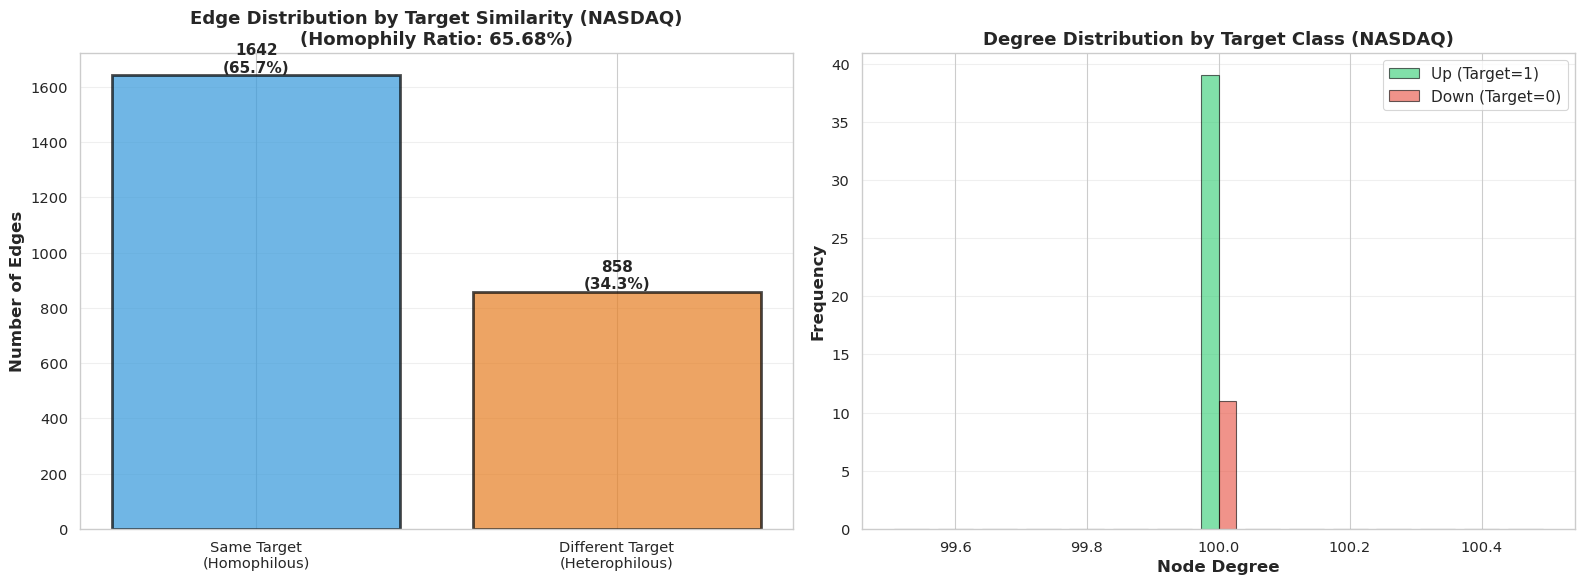


Homophily Analysis for Subgraph (NASDAQ):
Same-target edges (homophilous): 1642 (65.68%)
Different-target edges (heterophilous): 858 (34.32%)

Average degree of Up stocks: 100.00 ± 0.00
Average degree of Down stocks: 100.00 ± 0.00



In [81]:
# Analyze homophily in the subgraph
# Count edges between same-target nodes vs different-target nodes
same_target_edges = 0
diff_target_edges = 0

for u, v in G_sub.edges():
    if targets[u] == targets[v]:
        same_target_edges += 1
    else:
        diff_target_edges += 1

total_edges = same_target_edges + diff_target_edges
homophily_ratio = same_target_edges / total_edges if total_edges > 0 else 0

# Visualize homophily patterns
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left plot: Homophily ratio
ax1 = axes[0]
categories = ['Same Target\n(Homophilous)', 'Different Target\n(Heterophilous)']
counts = [same_target_edges, diff_target_edges]
colors_bar = ['#3498db', '#e67e22']

bars = ax1.bar(categories, counts, color=colors_bar, alpha=0.7, edgecolor='black', linewidth=2)
ax1.set_ylabel('Number of Edges', fontsize=12, fontweight='bold')
ax1.set_title(f'Edge Distribution by Target Similarity (NASDAQ)\n(Homophily Ratio: {homophily_ratio:.2%})', 
              fontsize=13, fontweight='bold')
ax1.grid(axis='y', alpha=0.3)

# Add value labels on bars
for bar, count in zip(bars, counts):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
            f'{count}\n({count/total_edges*100:.1f}%)',
            ha='center', va='bottom', fontsize=11, fontweight='bold')

# Right plot: Degree distribution by target class
ax2 = axes[1]
up_degrees = [G_sub.degree(node) for node in G_sub.nodes() if targets[node] == 1]
down_degrees = [G_sub.degree(node) for node in G_sub.nodes() if targets[node] == 0]

ax2.hist([up_degrees, down_degrees], bins=15, label=['Up (Target=1)', 'Down (Target=0)'],
         color=['#2ecc71', '#e74c3c'], alpha=0.6, edgecolor='black')
ax2.set_xlabel('Node Degree', fontsize=12, fontweight='bold')
ax2.set_ylabel('Frequency', fontsize=12, fontweight='bold')
ax2.set_title('Degree Distribution by Target Class (NASDAQ)', fontsize=13, fontweight='bold')
ax2.legend(fontsize=11)
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
save_figure(f'subgraph_homophily_analysis_snapshot_{SNAPSHOT_IDX}')
plt.show()

print(f"\n{'='*60}")
print(f"Homophily Analysis for Subgraph (NASDAQ):")
print(f"{'='*60}")
print(f"Same-target edges (homophilous): {same_target_edges} ({homophily_ratio:.2%})")
print(f"Different-target edges (heterophilous): {diff_target_edges} ({(1-homophily_ratio):.2%})")
if len(up_degrees) > 0:
    print(f"\nAverage degree of Up stocks: {np.mean(up_degrees):.2f} ± {np.std(up_degrees):.2f}")
if len(down_degrees) > 0:
    print(f"Average degree of Down stocks: {np.mean(down_degrees):.2f} ± {np.std(down_degrees):.2f}")
print(f"{'='*60}\n")

Figure saved to thesis_figures/NASDAQ/centrality_ranking_stability.pdf


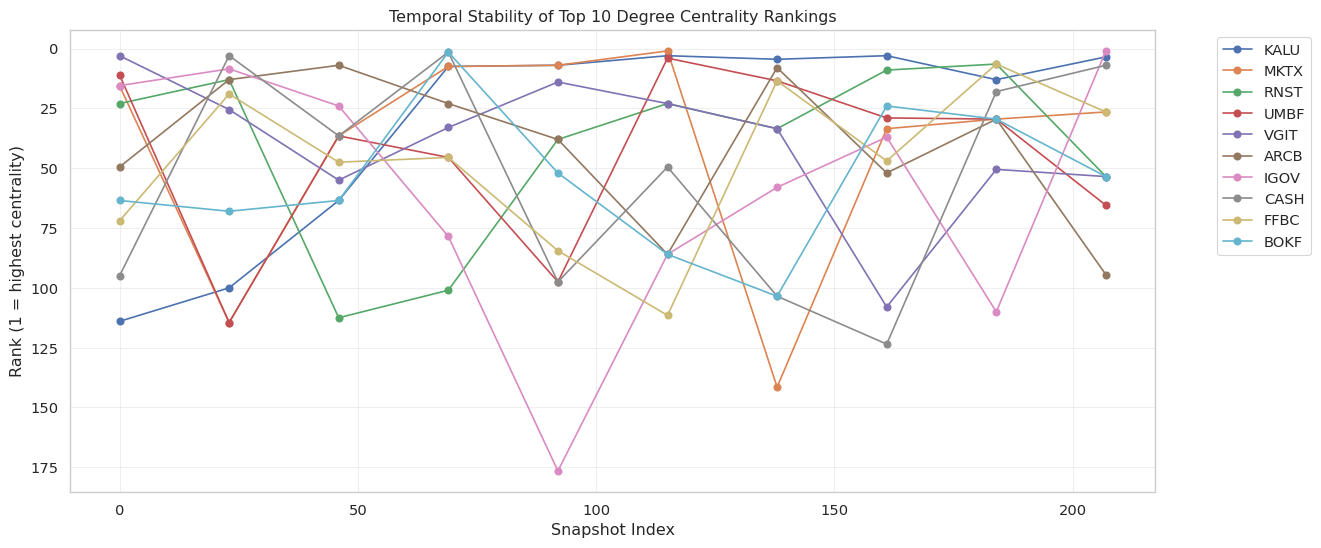

In [82]:
# Analyze temporal stability of centrality rankings
# For top 10 degree centrality nodes, track their ranking over time
top_10_nodes = centrality_df['Degree'].nlargest(10).index.tolist()
top_10_tickers = [train_analyzer.index_to_stock[i] for i in top_10_nodes]

degree_rankings_over_time = []
for idx in snapshot_indices:
    G = nx.from_numpy_array(train_adjs[idx], create_using=nx.DiGraph)
    deg_cent = pd.Series(nx.degree_centrality(G))
    rankings = {node: deg_cent.rank(ascending=False)[node] for node in top_10_nodes}
    degree_rankings_over_time.append(rankings)

ranking_df = pd.DataFrame(degree_rankings_over_time, index=snapshot_indices)
ranking_df.columns = top_10_tickers

plt.figure(figsize=(14, 6))
for ticker in ranking_df.columns:
    plt.plot(ranking_df.index, ranking_df[ticker], marker='o', label=ticker)
plt.gca().invert_yaxis()
plt.title('Temporal Stability of Top 10 Degree Centrality Rankings')
plt.xlabel('Snapshot Index')
plt.ylabel('Rank (1 = highest centrality)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
save_figure('centrality_ranking_stability')
plt.show()

---
## 4. Temporal Analysis of the Graph

### 4.1. Temporal Evolution of the Topology

Figure saved to thesis_figures/NASDAQ/temporal_adj_stability.pdf


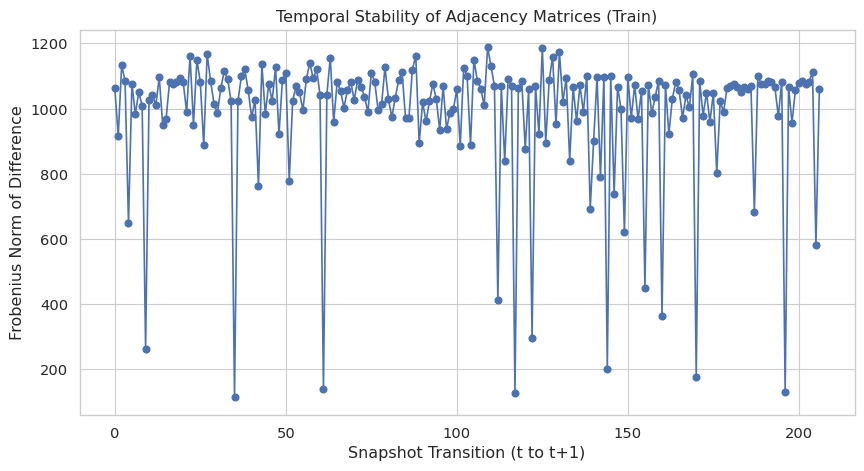

In [83]:
# Adjacency Matrix Stability
adj_diffs = []
for i in range(1, len(train_adjs)):
    diff = np.linalg.norm(train_adjs[i] - train_adjs[i-1], 'fro')
    adj_diffs.append(diff)

plt.figure(figsize=(10, 5))
plt.plot(adj_diffs, marker='o', linestyle='-')
plt.title('Temporal Stability of Adjacency Matrices (Train)')
plt.xlabel('Snapshot Transition (t to t+1)')
plt.ylabel('Frobenius Norm of Difference')
save_figure('temporal_adj_stability')
plt.show()

Figure saved to thesis_figures/NASDAQ/temporal_feature_trend.pdf


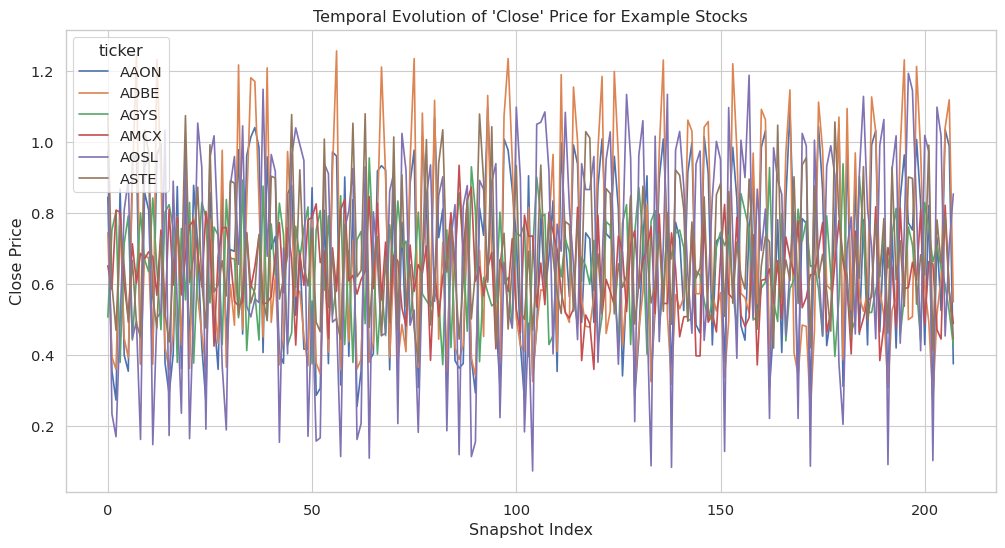

In [84]:
# Feature Evolution Over Time (example stocks)
example_stocks = [train_analyzer.index_to_stock[i] for i in [0, 10, 20, 30, 40, 50]]
ts_data = pd.DataFrame()
for stock in example_stocks:
    stock_ts = train_analyzer.get_feature_timeseries(stock_ticker=stock, feature='Close')
    ts_data = pd.concat([ts_data, stock_ts])

plt.figure(figsize=(12, 6))
sns.lineplot(data=ts_data, x='snapshot', y='value', hue='ticker')
plt.title("Temporal Evolution of 'Close' Price for Example Stocks")
plt.xlabel('Snapshot Index')
plt.ylabel('Close Price')
save_figure('temporal_feature_trend')
plt.show()

Figure saved to thesis_figures/NASDAQ/temporal_graph_metrics.pdf


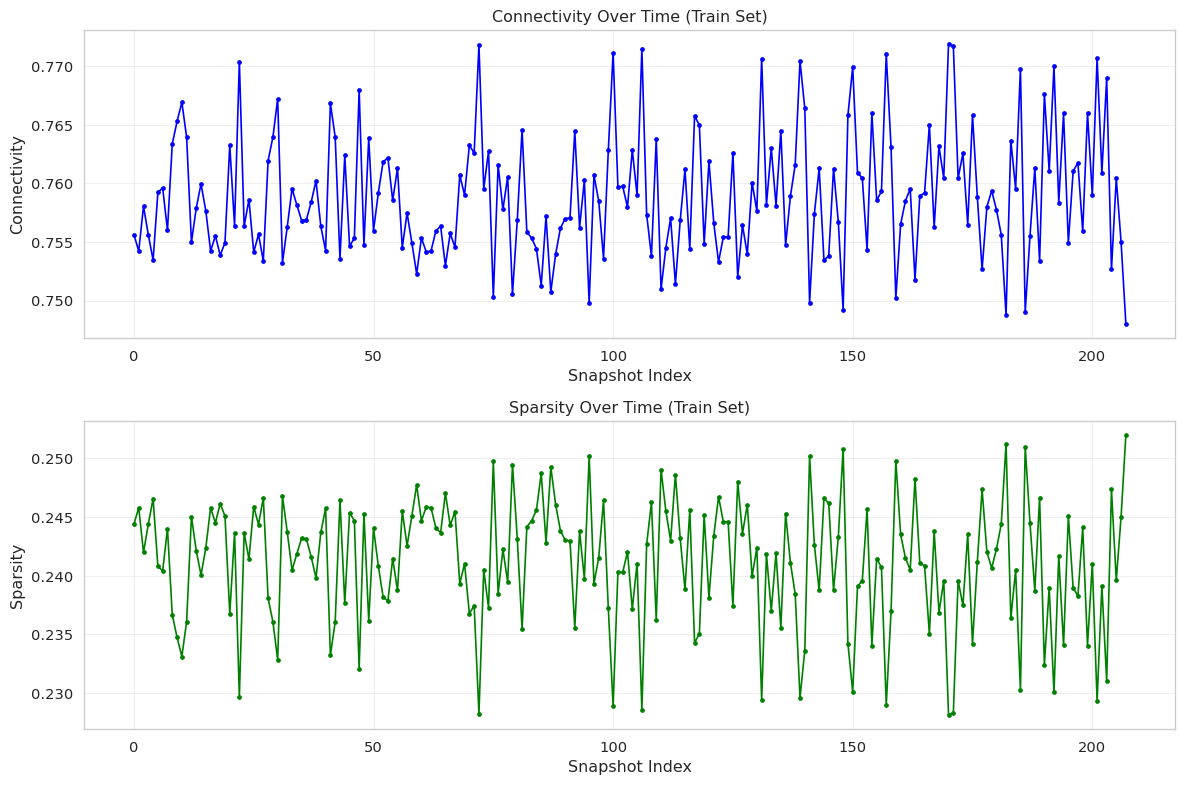

In [85]:
# Graph metrics evolution over time
connectivity_over_time = []
sparsity_over_time = []
for i in range(train_analyzer.num_snapshots):
    snapshot_info = train_analyzer.get_snapshot_info(i)
    connectivity_over_time.append(snapshot_info['connectivity'])
    num_nodes = snapshot_info['num_nodes']
    num_edges = snapshot_info['num_edges']
    possible_edges = num_nodes * (num_nodes - 1)
    sparsity = 1.0 - (num_edges / possible_edges) if possible_edges > 0 else 0.0
    sparsity_over_time.append(sparsity)

fig, axes = plt.subplots(2, 1, figsize=(12, 8))

axes[0].plot(connectivity_over_time, marker='.', linestyle='-', color='blue')
axes[0].set_title('Connectivity Over Time (Train Set)')
axes[0].set_xlabel('Snapshot Index')
axes[0].set_ylabel('Connectivity')
axes[0].grid(True, alpha=0.3)

axes[1].plot(sparsity_over_time, marker='.', linestyle='-', color='green')
axes[1].set_title('Sparsity Over Time (Train Set)')
axes[1].set_xlabel('Snapshot Index')
axes[1].set_ylabel('Sparsity')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
save_figure('temporal_graph_metrics')
plt.show()

### 4.2. Homophily Analysis Over Time

**Motivation**: Homophily is the principle that similar nodes tend to connect with each other. In our context, it measures whether stocks that go "Up" tend to be connected to other "Up" stocks (and vice-versa). A high homophily score (closer to 1) suggests that neighbor information is strongly indicative of a node's own class, which is a favorable condition for GNNs. A low score (closer to 0) indicates heterophily, where connections are more common between nodes of different classes, presenting a greater challenge for standard GNN models.

Figure saved to thesis_figures/NASDAQ/cross_dataset_homophily.pdf


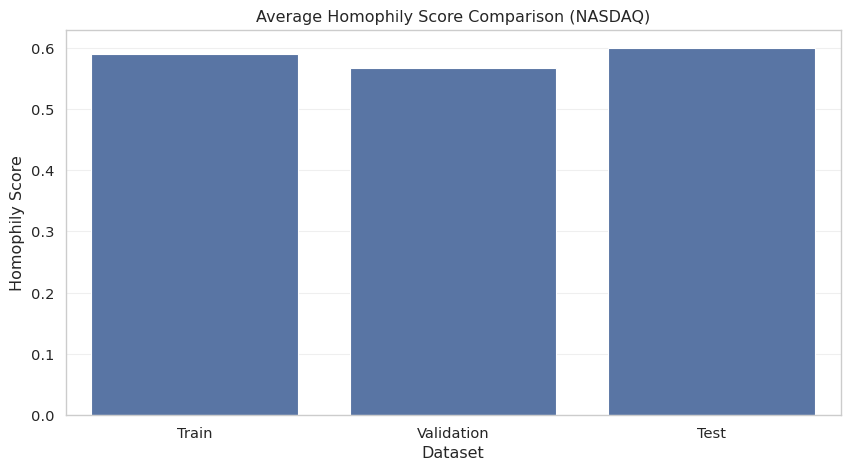

--- Average Homophily Scores (NASDAQ) ---


,Average Homophily
Train,0.590774
Validation,0.566743
Test,0.599590



--- LaTeX Table: Homophily Scores ---
\begin{table}
\caption{Average homophily scores for NASDAQ datasets.}
\label{tab:nasdaq_homophily}
\begin{tabular}{lr}
\toprule
 & Average Homophily \\
\midrule
Train & 0.5908 \\
Validation & 0.5667 \\
Test & 0.5996 \\
\bottomrule
\end{tabular}
\end{table}



In [86]:
# Average Homophily Score Comparison across datasets
homophily_scores = {name: analyzer.get_average_homophily_score() for name, analyzer in analyzers.items()}
homophily_df = pd.DataFrame.from_dict(homophily_scores, orient='index', columns=['Average Homophily'])

plt.figure(figsize=(10, 5))
sns.barplot(x=homophily_df.index, y=homophily_df['Average Homophily'])
plt.title('Average Homophily Score Comparison (NASDAQ)')
plt.ylabel('Homophily Score')
plt.xlabel('Dataset')
plt.grid(axis='y', alpha=0.3)
save_figure('cross_dataset_homophily')
plt.show()

print("--- Average Homophily Scores (NASDAQ) ---")
display(homophily_df)

# Save LaTeX table
print("\n--- LaTeX Table: Homophily Scores ---")
print(homophily_df.to_latex(caption='Average homophily scores for NASDAQ datasets.',
                            label='tab:nasdaq_homophily',
                            float_format="%.4f"))

Figure saved to thesis_figures/NASDAQ/temporal_homophily_train.pdf


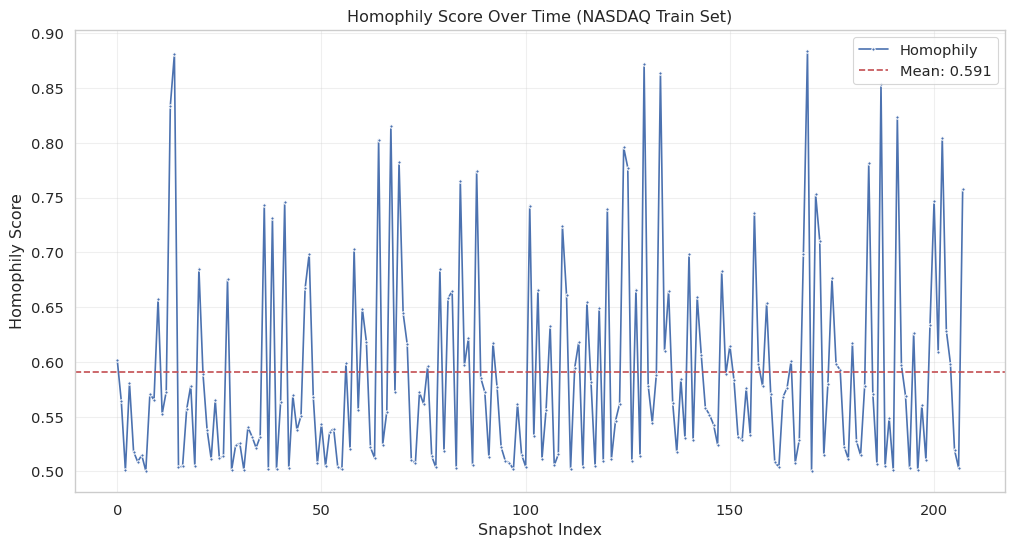

Figure saved to thesis_figures/NASDAQ/hist_homophily_train.pdf


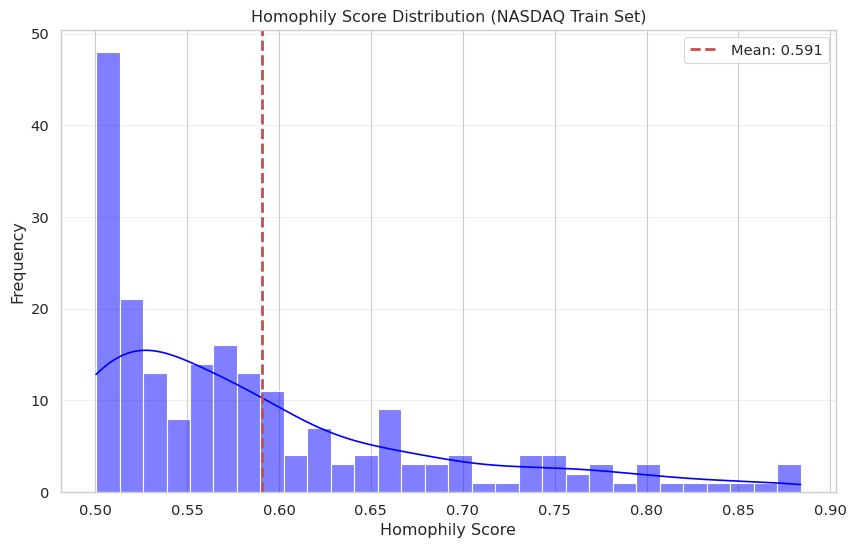


Homophily Statistics (NASDAQ Train Set):
Mean: 0.5908
Std: 0.0933
Min: 0.5005
Max: 0.8838



In [87]:
# Homophily Score Over Time (Train Set)
homophily_over_time = [train_analyzer.get_homophily_score(i) for i in range(train_analyzer.num_snapshots)]

plt.figure(figsize=(12, 6))
sns.lineplot(data=homophily_over_time, marker='.', linestyle='-', label='Homophily')
plt.axhline(y=np.mean(homophily_over_time), color='r', linestyle='--', 
            label=f'Mean: {np.mean(homophily_over_time):.3f}')
plt.title('Homophily Score Over Time (NASDAQ Train Set)')
plt.xlabel('Snapshot Index')
plt.ylabel('Homophily Score')
plt.legend()
plt.grid(True, alpha=0.3)
save_figure('temporal_homophily_train')
plt.show()

# Homophily distribution
plt.figure(figsize=(10, 6))
sns.histplot(homophily_over_time, bins=30, kde=True, color='blue', alpha=0.5)
plt.axvline(x=np.mean(homophily_over_time), color='r', linestyle='--', linewidth=2,
            label=f'Mean: {np.mean(homophily_over_time):.3f}')
plt.title('Homophily Score Distribution (NASDAQ Train Set)')
plt.xlabel('Homophily Score')
plt.ylabel('Frequency')
plt.legend()
plt.grid(True, axis='y', alpha=0.3)
save_figure('hist_homophily_train')
plt.show()

# Statistics
print(f"\n{'='*60}")
print(f"Homophily Statistics (NASDAQ Train Set):")
print(f"{'='*60}")
print(f"Mean: {np.mean(homophily_over_time):.4f}")
print(f"Std: {np.std(homophily_over_time):.4f}")
print(f"Min: {np.min(homophily_over_time):.4f}")
print(f"Max: {np.max(homophily_over_time):.4f}")
print(f"{'='*60}\n")

### 4.3. Graph Hyperbolicity Analysis

**Motivation**: Graph hyperbolicity (measured via Gromov δ-hyperbolicity) quantifies how "tree-like" a graph is. Lower δ values indicate more tree-like structure, while higher values suggest more grid-like or complex topology. This is important because:
- Tree-like graphs (low δ) are well-suited for hierarchical models
- Different GNN architectures perform better on different graph topologies
- Hyperbolicity can reveal the underlying structure of market relationships

We compute the δ-hyperbolicity for sampled quadruples across snapshots to assess the temporal stability of graph topology.

In [ ]:
# Sample up to 500 quadruples per snapshot to keep runtime manageable.
SAMPLE_SIZE = 500
RANDOM_STATE = 42
hyperbolicity_summary = []
hyperbolicity_by_snapshot = []

print("Computing hyperbolicity across datasets...")
for split_name, split_analyzer in analyzers.items():
    print(f"\nProcessing {split_name}...")
    snapshot_scores = []
    for idx in range(split_analyzer.num_snapshots):
        if idx % 10 == 0:
            print(f"  Snapshot {idx}/{split_analyzer.num_snapshots}...", end='\r')
        score = split_analyzer.compute_snapshot_hyperbolicity(idx, sample_size=SAMPLE_SIZE, random_state=RANDOM_STATE)
        snapshot_scores.append(score)
    
    print(f"\n  {split_name} complete: Mean δ = {np.mean(snapshot_scores):.4f}")
    
    if not snapshot_scores:
        continue
    hyperbolicity_summary.append({
        "split": split_name,
        "avg_delta": float(np.mean(snapshot_scores)),
        "std_delta": float(np.std(snapshot_scores)),
        "max_delta": float(np.max(snapshot_scores)),
        "min_delta": float(np.min(snapshot_scores))
    })
    hyperbolicity_by_snapshot.append(pd.DataFrame({
        "split": split_name,
        "snapshot_index": range(len(snapshot_scores)),
        "delta_hyperbolicity": snapshot_scores
    }))

hyperbolicity_summary_df = pd.DataFrame(hyperbolicity_summary).sort_values("avg_delta")
print("\n--- Hyperbolicity Summary (NASDAQ) ---")
display(hyperbolicity_summary_df)

# Save LaTeX table
print("\n--- LaTeX Table: Hyperbolicity Summary ---")
print(hyperbolicity_summary_df.to_latex(caption='Hyperbolicity summary for NASDAQ datasets.',
                                        label='tab:nasdaq_hyperbolicity',
                                        float_format="%.4f",
                                        index=False))

# Plot hyperbolicity over snapshots
hyperbolicity_by_snapshot_df = pd.concat(hyperbolicity_by_snapshot, ignore_index=True) if hyperbolicity_by_snapshot else pd.DataFrame()
if not hyperbolicity_by_snapshot_df.empty:
    plt.figure(figsize=(12, 6))
    sns.lineplot(data=hyperbolicity_by_snapshot_df, x="snapshot_index", y="delta_hyperbolicity", 
                 hue="split", marker="o", markersize=4)
    plt.title("δ-Hyperbolicity Over Snapshots (NASDAQ)")
    plt.ylabel("δ-Hyperbolicity")
    plt.xlabel("Snapshot Index")
    plt.legend(title='Dataset')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    save_figure('hyperbolicity_across_datasets')
    plt.show()
else:
    print("No hyperbolicity values were computed.")

Computing hyperbolicity across datasets...

Processing Train...


---
## Analysis Complete

All figures have been saved to: `thesis_figures/NASDAQ/`